# **MASTER THESIS - COVER_TYPE DATASET MODELING PIPELINE**

## 🎓 Master’s Thesis in Data Science & Advanced Analytics
**Nova IMS** | 2026
**Course:** Resarch and Methodology part 2

## 👥 Author
- **Philippe Dutranoit** | 20240518

📊 Goal of the notebook

This thesis focuses on benchmarking interpretability and hybrid modeling techniques across multiple evaluation metrics, aiming to balance predictive performance with model transparency.

This notebook is dedicated to the Covertype dataset, which is used to evaluate and compare model behavior in a multiclass classification setting. Unlike binary classification tasks, this dataset introduces additional complexity, making it particularly suitable for analyzing how the three hybrid models perform when handling multiple classes. The goal is to assess their effectiveness, robustness, and interpretability in a more challenging and realistic scenario.

**Each Experimental file is structured the same way the main difference being the Dataset it-self and therefore all the potential result associated with it**

## Table of Contents

- **Imports and Preprocessing**
- **Model Optimisation**
- **Model Final Training**
- **Model Metric Extraction**
  - **Computational Cost (Time with explanations)**
  - **Performance metrics**
  - **Overfitting**
  - **Faithfulness**
  - **Stability**
  - **Sparsity**
  - **Hybrid transparency**
- **Results**
- **Export**

<hr>
<a class="anchor" id="setup">

# Imports and Preprocessing

In this section, we import the relevant dataset and apply preprocessing steps specific to that dataset.

The pipeline is intentionally simple: some datasets are already partially preprocessed at import, and the primary objective is to compare model performance across approaches.

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, log_loss
from sklearn.model_selection import train_test_split
from collections import defaultdict
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml

from Models_Functions import *
from Grid_Search_Functions import *
from Metrics_Functions import *
from Graph_Functions import *

import importlib
imported_module = importlib.import_module("Models_Functions")
importlib.reload(imported_module)
imported_module = importlib.import_module("Grid_Search_Functions")
importlib.reload(imported_module)
imported_module = importlib.import_module("Metrics_Functions")
importlib.reload(imported_module)
imported_module = importlib.import_module("Graph_Functions")
importlib.reload(imported_module)

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'Graph_Functions' from '/Users/philippedutranoit/document_ordi/nova/Thesis_Repository/Graph_Functions.py'>

In [ ]:
path_graph= "../Graphs/Cover_type"

covertype = fetch_openml(name="covertype", version=3, as_frame=True)

X = covertype.data
y = covertype.target

le = LabelEncoder()
y = le.fit_transform(y).astype(np.int32)

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

# Split first; CoverType is already preprocessed (numeric + one-hot style columns)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.20, stratify=y_train, random_state=42
)

raw_feature_names = X_train.columns.astype(str).tolist()

# Force pipeline-compatible prefixes for downstream logic
cat_patterns = ("Wilderness_Area", "Soil_Type", "wilderness_area", "soil_type")
feature_names = [
    f"cat__{name}" if any(pat in name for pat in cat_patterns) else f"num__{name}"
    for name in raw_feature_names
]

# Convert to numpy for model code consistency
X_train = X_train.to_numpy(dtype=np.float32)
X_val = X_val.to_numpy(dtype=np.float32)
X_test = X_test.to_numpy(dtype=np.float32)

print("X_train shape:", X_train.shape)
print("y_train bincount:", np.bincount(y_train))
print("n_features:", len(feature_names))
print("example feature names:", feature_names[:15])

n_num = len(num_cols)
n_total = X_train.shape[1]

categorical_mask = np.array([False] * n_num + [True] * (n_total - n_num))
numeric_mask = np.array([True] * n_num + [False] * (n_total - n_num))

group_dict = defaultdict(list)

for idx, name in enumerate(feature_names):
    if name.startswith("cat__"):
        # Example: "cat__workclass_Private"
        remainder = name[len("cat__"):]
        original_var = remainder.split("_", 1)[0]
        group_dict[original_var].append(idx)

categorical_groups = list(group_dict.values())

print("Number of categorical groups:", len(categorical_groups))
print("Example group:", categorical_groups[0])

X_train shape: (418328, 54)
y_train bincount: [152525 203976  25743   1978   6835  12504  14767]
n_features: 54
example feature names: ['num__Elevation', 'num__Aspect', 'num__Slope', 'num__Horizontal_Distance_To_Hydrology', 'num__Vertical_Distance_To_Hydrology', 'num__Horizontal_Distance_To_Roadways', 'num__Hillshade_9am', 'num__Hillshade_Noon', 'num__Hillshade_3pm', 'num__Horizontal_Distance_To_Fire_Points', 'cat__Wilderness_Area1', 'cat__Wilderness_Area2', 'cat__Wilderness_Area3', 'cat__Wilderness_Area4', 'cat__Soil_Type1']
Number of categorical groups: 2
Example group: [10, 11, 12, 13]


<hr>
<a class="anchor" id="setup">

# Model Optimisation

In this section, we perform model optimization to ensure each model operates near its best capacity.

We use a grid search strategy with parameter ranges broad enough to explore meaningful configurations while remaining computationally feasible, given the available hardware (MacBook Air M1).

In [ ]:

param_grid = {
    "hidden": [(64, 64), (128, 64), (128, 128)],
    "dropout": [0.0, 0.2],
    "l2": [1e-4, 1e-3],
    "lr": [3e-4, 1e-3],
    "batch_size": [64],
    "epochs": [50]
}

_, _, best_params_mlp = grid_search_MLP(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    fit_fn=fit_blackbox_mlp,
    param_grid=param_grid
)



[1/24] Trying: {'hidden': (64, 64), 'dropout': 0.0, 'l2': 0.0001, 'lr': 0.0003, 'batch_size': 64, 'epochs': 50}
Epoch 1/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - acc: 0.6929 - loss: 0.7775 - val_acc: 0.7716 - val_loss: 0.5422 - learning_rate: 3.0000e-04
Epoch 2/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - acc: 0.7691 - loss: 0.5485 - val_acc: 0.7933 - val_loss: 0.4920 - learning_rate: 3.0000e-04
Epoch 3/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 6s 944us/step - acc: 0.7860 - loss: 0.5090 - val_acc: 0.8077 - val_loss: 0.4666 - learning_rate: 3.0000e-04
Epoch 4/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 6s 955us/step - acc: 0.7945 - loss: 0.4900 - val_acc: 0.8142 - val_loss: 0.4483 - learning_rate: 3.0000e-04
Epoch 5/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 6s 959us/step - acc: 0.8033 - loss: 0.4728 - val_acc: 0.8228 - val_loss: 0.4331 - learning_rate: 3.0000e-04
Epoch 6/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - acc: 0.8089 - loss: 0.4592 - val_acc: 0.8291 - val_loss: 0.4210 - learning_rate: 3.00

In [11]:
param_grid_nam = {
    "hidden": [(16,), (32,), (32, 16)],
    "dropout": [0.0, 0.2],
    "l2": [5e-4, 1e-3, 5e-3],
    "lr": [3e-4],
    "batch_size": [64],
    "epochs": [50]
}

_, _, best_params_nam = grid_search_nam(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    fit_fn=fit_nam,
    param_grid=param_grid_nam
)


[1/18] Trying: {'hidden': (16,), 'dropout': 0.0, 'l2': 0.0005, 'lr': 0.0003, 'batch_size': 64, 'epochs': 50}
Epoch 1/50


KeyboardInterrupt: 

In [13]:
hybrid_logreg_param_grid = {
    "tau": [0.7, 0.8, 0.9],
    "logreg_C": [0.1, 1.0, 10.0],
    "logreg_penalty": ["l2"],
    "logreg_solver": ["lbfgs"],
    "logreg_class_weight": [None],
    "hidden": [(64, 64), (128, 64)],
    "dropout": [0.0, 0.2],
    "l2": [1e-4, 1e-3],
    "lr": [3e-4, 1e-3],
    "batch_size": [64],
    "epochs": [50]
}

_, _, best_params_hybrid = grid_search_hybrid_logreg_mlp(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    fit_fn=fit_hybrid_logreg_mlp,
    param_grid=hybrid_logreg_param_grid
)


[1/144] Trying: {'tau': 0.7, 'logreg_C': 0.1, 'logreg_penalty': 'l2', 'logreg_solver': 'lbfgs', 'logreg_class_weight': None, 'hidden': (64, 64), 'dropout': 0.0, 'l2': 0.0001, 'lr': 0.0003, 'batch_size': 64, 'epochs': 50}


KeyboardInterrupt: 

In [ ]:
# model parameter save (automatically mapped from grid search best params)

MLP_hidden = best_params_mlp["hidden"]
MLP_dropout = best_params_mlp["dropout"]
MLP_l2 = best_params_mlp["l2"]
MLP_lr = best_params_mlp["lr"]
MLP_epochs = best_params_mlp["epochs"]
MLP_batch_size = best_params_mlp["batch_size"]

NAM_hidden = best_params_nam["hidden"]
NAM_dropout = best_params_nam["dropout"]
NAM_l2 = best_params_nam["l2"]
NAM_lr = best_params_nam["lr"]
NAM_epochs = best_params_nam["epochs"]
NAM_batch_size = best_params_nam["batch_size"]

hybrid_tau = best_params_hybrid["tau"]
hybrid_logreg_C = best_params_hybrid["logreg_C"]
hybrid_logreg_penalty = best_params_hybrid["logreg_penalty"]
hybrid_logreg_solver = best_params_hybrid["logreg_solver"]
hybrid_logreg_class_weight = best_params_hybrid["logreg_class_weight"]
hybrid_hidden = best_params_hybrid["hidden"]
hybrid_dropout = best_params_hybrid["dropout"]
hybrid_l2 = best_params_hybrid["l2"]
hybrid_lr = best_params_hybrid["lr"]
hybrid_epochs = best_params_hybrid["epochs"]
hybrid_batch_size = best_params_hybrid["batch_size"]

<hr>
<a class="anchor" id="setup">

# Model Final Training

In this section, we run the final models using the optimal parameters identified in the previous section.

Although these are the final trained models, they are not used as the main basis for the evaluation protocol. Instead, they are used as a final sanity check to verify that the models run correctly with the selected parameters.

These final runs are also used to inspect global feature importance, in order to obtain an initial understanding of which variables contribute most to the predictions. In addition, the training and validation behavior is examined to check for potential abnormalities, such as unstable learning dynamics or clear signs of overfitting.

Epoch 1/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - acc: 0.7171 - loss: 0.6983 - val_acc: 0.7825 - val_loss: 0.5200 - learning_rate: 3.0000e-04
Epoch 2/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - acc: 0.7823 - loss: 0.5197 - val_acc: 0.8115 - val_loss: 0.4609 - learning_rate: 3.0000e-04
Epoch 3/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - acc: 0.8039 - loss: 0.4744 - val_acc: 0.8285 - val_loss: 0.4253 - learning_rate: 3.0000e-04
Epoch 4/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - acc: 0.8153 - loss: 0.4503 - val_acc: 0.8312 - val_loss: 0.4184 - learning_rate: 3.0000e-04
Epoch 5/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - acc: 0.8259 - loss: 0.4292 - val_acc: 0.8396 - val_loss: 0.3940 - learning_rate: 3.0000e-04
Epoch 6/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - acc: 0.8319 - loss: 0.4150 - val_acc: 0.8521 - val_loss: 0.3738 - learning_rate: 3.0000e-04
Epoch 7/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - acc: 0.8382 - loss: 0.4028 - val_acc: 0.8532 - val_loss

/opt/homebrew/lib/python3.11/site-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: X
Received: inputs=['Tensor(shape=(104582, 54))']
  warnings.warn(msg)
/opt/homebrew/lib/python3.11/site-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: X
Received: inputs=['Tensor(shape=(50, 54))']
  warnings.warn(msg)



[POST BLACK-BOX: MLP]
Test Accuracy: 0.9094007090977936
Test Log-loss: 0.22816458095471115


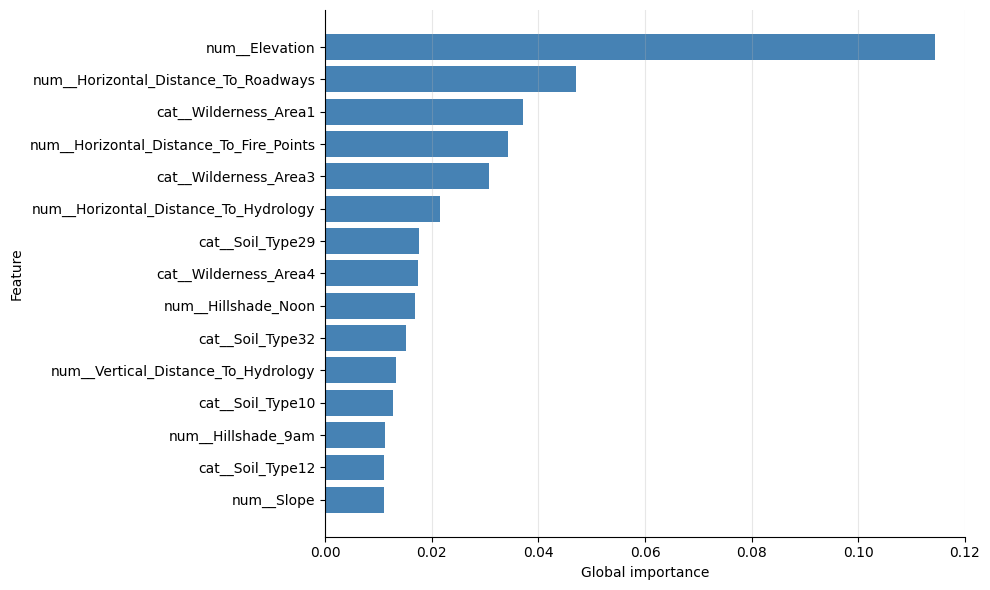

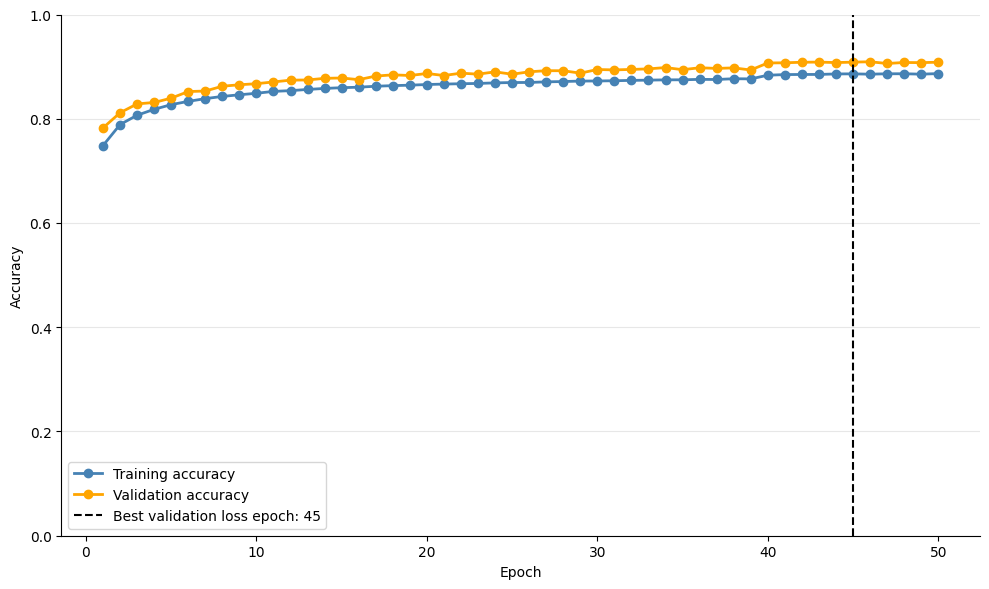

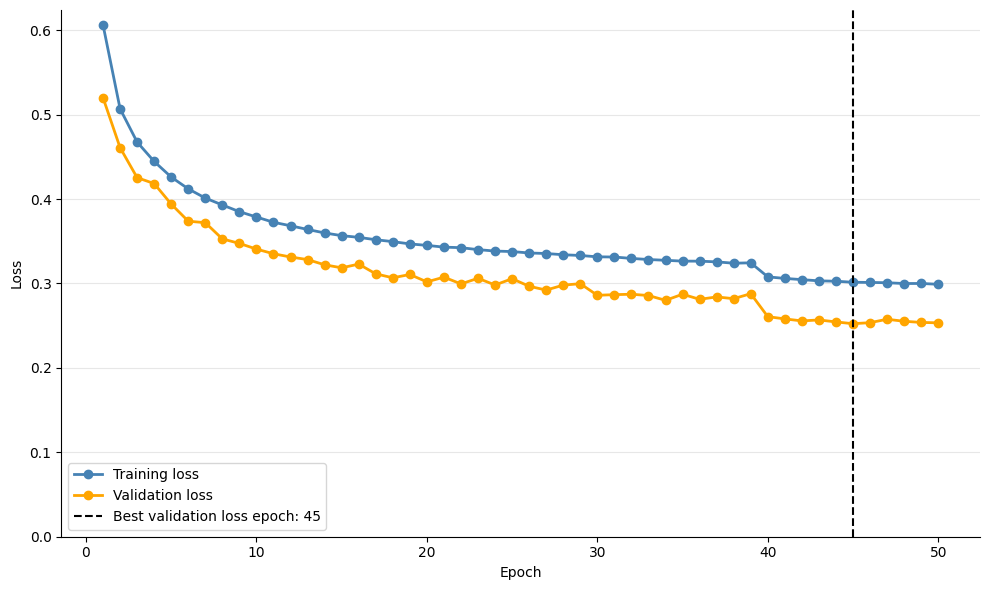

(<Axes: xlabel='Epoch', ylabel='Loss'>,
 'Graphs/Cover_type/mlp_trainVSval_Loss.png')

In [5]:
bb_model, mlp_history, mlp_contribs = fit_blackbox_mlp(X_train, y_train, X_val, y_val, hidden=MLP_hidden, dropout=MLP_dropout, l2=MLP_l2, lr=MLP_lr, epochs=MLP_epochs, batch_size=MLP_batch_size)

P_bb = bb_model.predict(X_test, verbose=0)
y_bb = np.argmax(P_bb, axis=1)
print("\n[POST BLACK-BOX: MLP]")
print("Test Accuracy:", accuracy_score(y_test, y_bb))
print("Test Log-loss:", log_loss(y_test, P_bb))

mlp_local_importance = get_local_importance(mlp_contribs)
mlp_global_importance = get_global_importance(mlp_contribs)

plot_top_global_importance(mlp_global_importance, feature_names, name="MLP", top_n=15, save_path=path_graph, save_title="MLP_Global_Importance")

plot_train_val_accuracy(mlp_history, model_name="Post-Black-Box", save_path=path_graph, save_title="mlp_trainVSval_accuracy")

plot_train_val_loss(mlp_history, model_name="Post-Black-Box", save_path=path_graph, save_title="mlp_trainVSval_Loss")


Epoch 1/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 53s 6ms/step - acc: 0.6434 - loss: 0.8845 - val_acc: 0.7127 - val_loss: 0.6986 - learning_rate: 3.0000e-04
Epoch 2/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step - acc: 0.7161 - loss: 0.6858 - val_acc: 0.7209 - val_loss: 0.6651 - learning_rate: 3.0000e-04
Epoch 3/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step - acc: 0.7217 - loss: 0.6610 - val_acc: 0.7244 - val_loss: 0.6543 - learning_rate: 3.0000e-04
Epoch 4/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step - acc: 0.7225 - loss: 0.6540 - val_acc: 0.7263 - val_loss: 0.6468 - learning_rate: 3.0000e-04
Epoch 5/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step - acc: 0.7250 - loss: 0.6469 - val_acc: 0.7284 - val_loss: 0.6439 - learning_rate: 3.0000e-04
Epoch 6/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step - acc: 0.7265 - loss: 0.6428 - val_acc: 0.7265 - val_loss: 0.6422 - learning_rate: 3.0000e-04
Epoch 7/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step - acc: 0.7270 - loss: 0.6398 - val_acc: 0.7253 - va

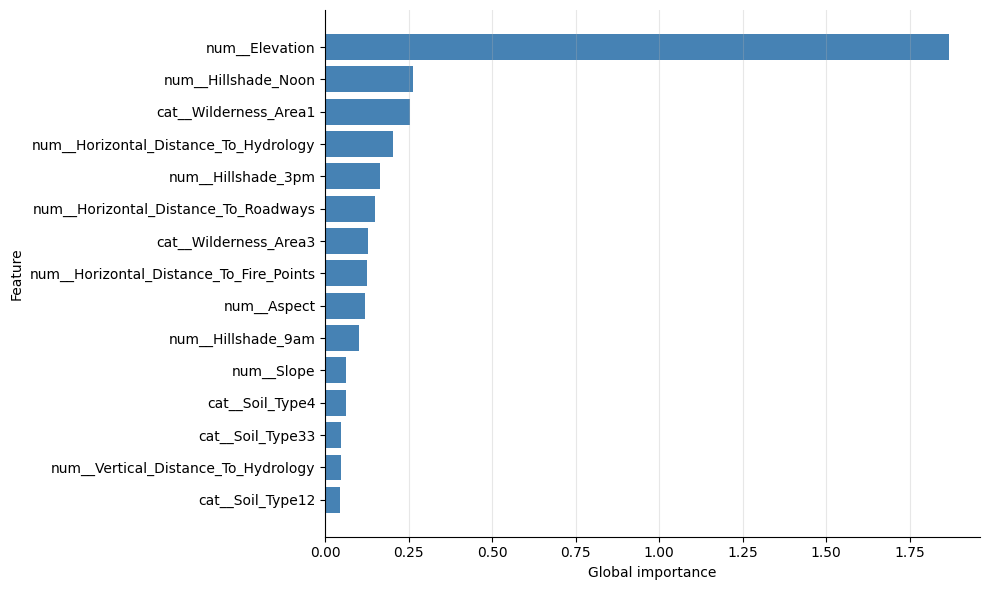

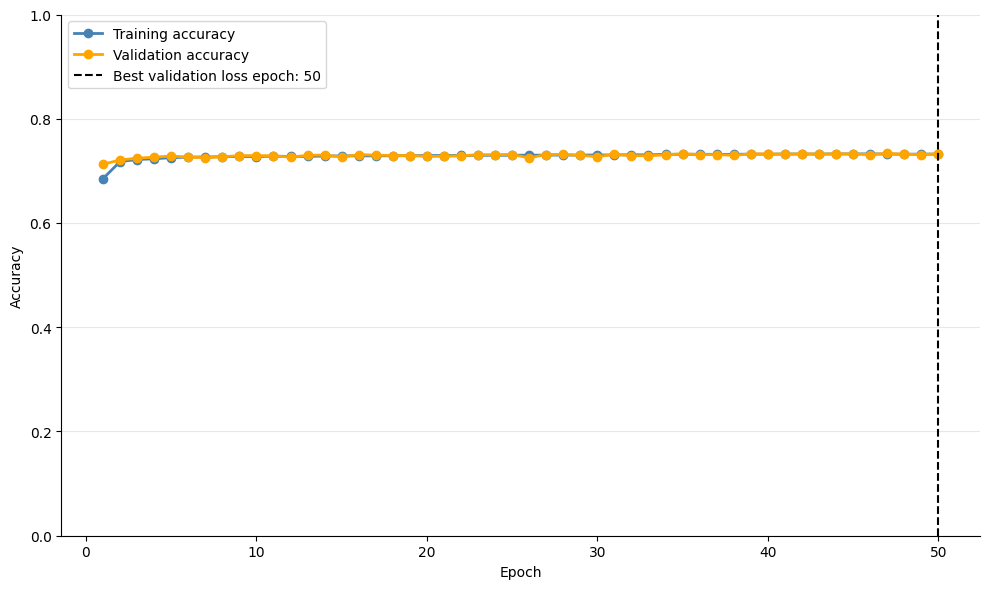

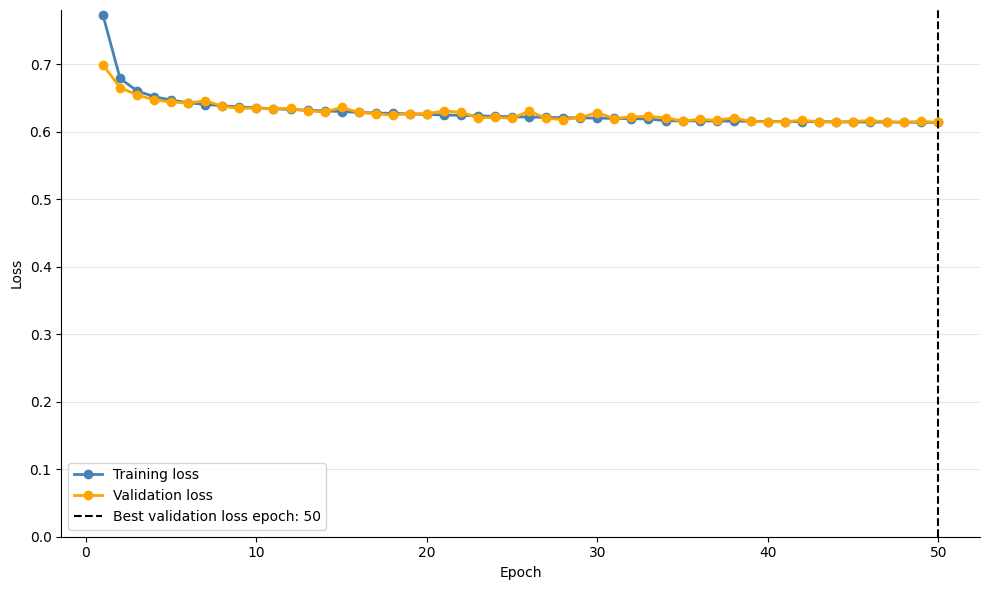

(<Axes: xlabel='Epoch', ylabel='Loss'>,
 'Graphs/Cover_type/nam_trainVSval_Loss.png')

In [6]:
nam_model, nam_history, nam_contribs, nam_feature_nets = fit_nam(X_train, y_train, X_val, y_val, hidden=NAM_hidden, dropout=NAM_dropout, l2=NAM_l2, lr=NAM_lr, epochs=NAM_epochs, batch_size=NAM_batch_size)

P_nam = nam_model.predict(X_test, verbose=0)
y_nam = np.argmax(P_nam, axis=1)
print("\n[NAM]")
print("Test Accuracy:", accuracy_score(y_test, y_nam))
print("Test Log-loss:", log_loss(y_test, P_nam))

nam_contr = get_nam_contributions(nam_contribs, X_test)
nam_local_importance = get_local_importance(nam_contr)
nam_global_importance = get_global_importance(nam_contr)

plot_top_global_importance(nam_global_importance, feature_names, name="NAM", top_n=15, save_path=path_graph, save_title="NAM_Global_Importance")

plot_train_val_accuracy(nam_history, model_name="NAM", save_path=path_graph, save_title="nam_trainVSval_accuracy")

plot_train_val_loss(nam_history, model_name="NAM", save_path=path_graph, save_title="nam_trainVSval_Loss")

Epoch 1/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - acc: 0.6962 - loss: 0.8052 - val_acc: 0.7694 - val_loss: 0.5687 - learning_rate: 0.0010
Epoch 2/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - acc: 0.7555 - loss: 0.6062 - val_acc: 0.7859 - val_loss: 0.5437 - learning_rate: 0.0010
Epoch 3/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - acc: 0.7648 - loss: 0.5899 - val_acc: 0.7860 - val_loss: 0.5350 - learning_rate: 0.0010
Epoch 4/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - acc: 0.7690 - loss: 0.5852 - val_acc: 0.7997 - val_loss: 0.5228 - learning_rate: 0.0010
Epoch 5/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - acc: 0.7715 - loss: 0.5790 - val_acc: 0.7916 - val_loss: 0.5269 - learning_rate: 0.0010
Epoch 6/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - acc: 0.7747 - loss: 0.5753 - val_acc: 0.7977 - val_loss: 0.5218 - learning_rate: 0.0010
Epoch 7/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - acc: 0.7756 - loss: 0.5742 - val_acc: 0.7960 - val_loss: 0.5256 - learning_rate:

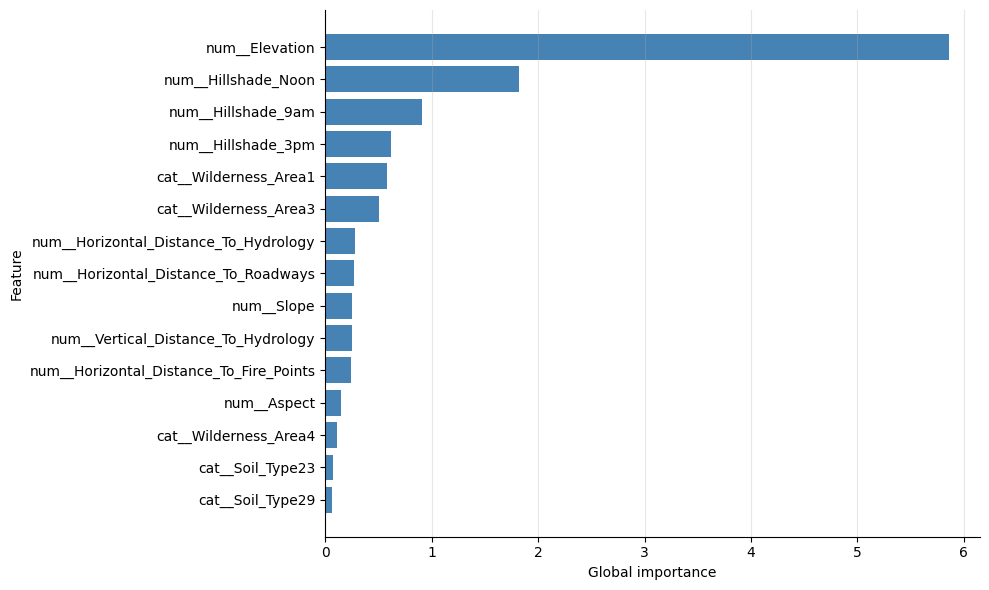

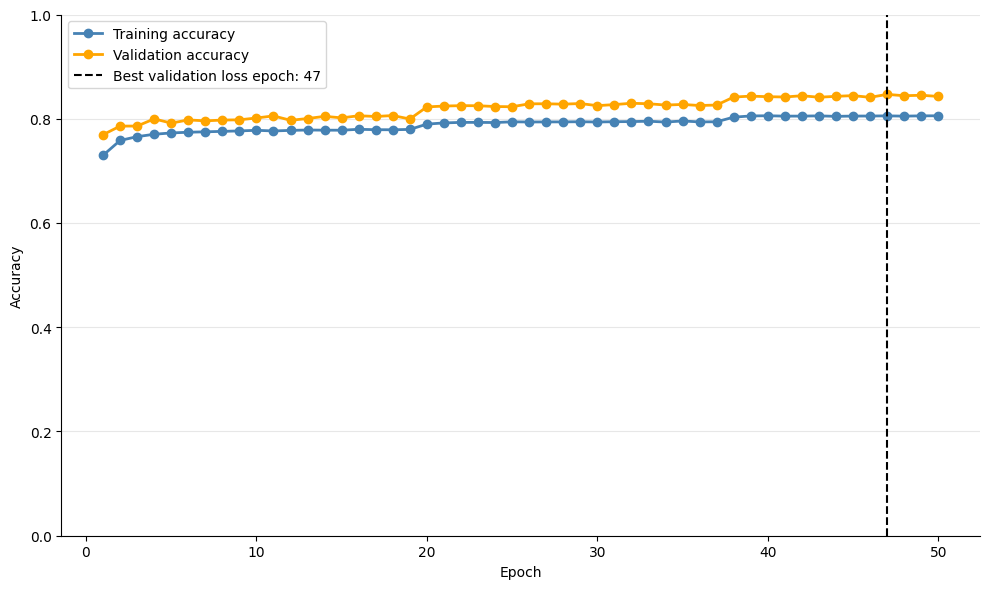

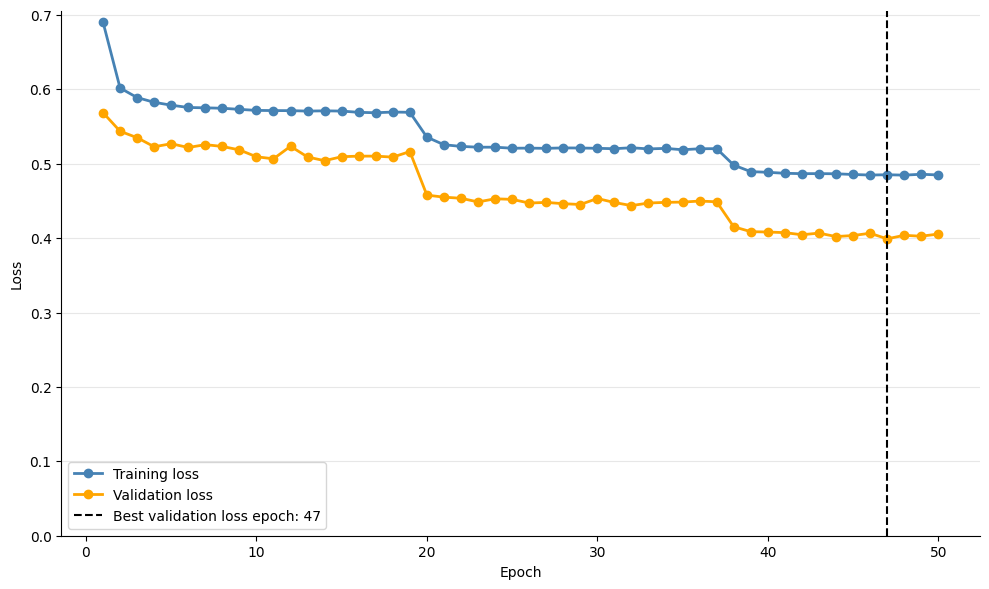

(<Axes: xlabel='Epoch', ylabel='Loss'>,
 'Graphs/Cover_type/hybrid_trainVSval_Loss.png')

In [7]:
logreg_model, MLP_hybrid, hybrid_history, hybrid_contrib = fit_hybrid_logreg_mlp(X_train, y_train, X_val, y_val, tau=hybrid_tau, logreg_C=hybrid_logreg_C, logreg_penalty=hybrid_logreg_penalty, logreg_solver=hybrid_logreg_solver, logreg_class_weight=hybrid_logreg_class_weight, hidden=hybrid_hidden, dropout=hybrid_dropout, l2=hybrid_l2, lr=hybrid_lr, epochs=hybrid_epochs, batch_size=hybrid_batch_size)

P_lr_test = logreg_model.predict_proba(X_test)
eval_probs(y_test, P_lr_test, name="Logistic Regression only")
P_bb_test = MLP_hybrid.predict(X_test, verbose=0)
eval_probs(y_test, P_bb_test, name="Black-box MLP only")


P_hybrid_test, use_logreg_test, _ = hybrid_predict(
    logreg_model, MLP_hybrid, X_test, tau=hybrid_tau
)

eval_probs(y_test, P_hybrid_test, name=f"Hybrid LogReg+MLP (τ={TAU})")
print(f"Hybrid transparency: {use_logreg_test.mean():.3f}")

hybrid_local_importance = get_local_importance(hybrid_contrib)
hybrid_global_importance = get_global_importance(hybrid_contrib)

plot_top_global_importance(hybrid_global_importance, feature_names, name="Hybrid LogReg+MLP", top_n=15, save_path=path_graph, save_title="Hybrid_Global_Importance")

plot_train_val_accuracy(hybrid_history, model_name="Pre-Black-Box(mlp_part)", save_path=path_graph, save_title="hybrid_trainVSval_accuracy")

plot_train_val_loss(hybrid_history, model_name="Pre-Black-Box(mlp_part)", save_path=path_graph, save_title="hybrid_trainVSval_Loss")

<hr>
<a class="anchor" id="setup">

# Model Metric Extraction

In this section, we compute the final evaluation metrics for the three model approaches across several dimensions:

- **Predictive performance**
- **Computational cost**
- **Faithfulness**
- **Stability**
- **Sparsity**
- **Overfitting**
- **Hybrid transparency**

This evaluation is designed to compare the models not only in terms of predictive quality, but also in terms of interpretability, robustness, computational efficiency, and generalization behavior.

To account for randomness in the training process, each model is trained and evaluated across **five independent runs**. For predictive performance, overfitting, faithfulness, stability, and sparsity, the final reported values correspond to the **mean and standard deviation across the five runs**.

Computational cost is also measured across the repeated runs by recording the training and prediction time for each model. This allows us to compare the average computational burden of each approach while also accounting for variability across runs.

For the hybrid model, an additional metric is reported: the **transparency rate**. This measures the proportion of predictions handled directly by the Logistic Regression component instead of being passed to the MLP. Since this metric only applies to the hybrid model, it is reported separately from the metrics shared by all three approaches.

Overall, this protocol provides a more reliable comparison than a single run, because it accounts for variability caused by random initialization, training dynamics, and explanation computation.

In [ ]:
results_df = pd.DataFrame({"Model": ["MLP+SHAP", "NAM", "LogReg+MLP"]})

In [9]:
# we train 5 model for each type to get a distribution of results and importance scores. This allows us to report mean and std for metrics and importance scores across 5 runs.

# MLP models (5 runs)
bb_model_1, mlp_history_1, mlp_contribs_1 = fit_blackbox_mlp(X_train, y_train, X_val, y_val, hidden=MLP_hidden, dropout=MLP_dropout, l2=MLP_l2, lr=MLP_lr, epochs=MLP_epochs, batch_size=MLP_batch_size)
bb_model_2, mlp_history_2, mlp_contribs_2 = fit_blackbox_mlp(X_train, y_train, X_val, y_val, hidden=MLP_hidden, dropout=MLP_dropout, l2=MLP_l2, lr=MLP_lr, epochs=MLP_epochs, batch_size=MLP_batch_size)
bb_model_3, mlp_history_3, mlp_contribs_3 = fit_blackbox_mlp(X_train, y_train, X_val, y_val, hidden=MLP_hidden, dropout=MLP_dropout, l2=MLP_l2, lr=MLP_lr, epochs=MLP_epochs, batch_size=MLP_batch_size)
bb_model_4, mlp_history_4, mlp_contribs_4 = fit_blackbox_mlp(X_train, y_train, X_val, y_val, hidden=MLP_hidden, dropout=MLP_dropout, l2=MLP_l2, lr=MLP_lr, epochs=MLP_epochs, batch_size=MLP_batch_size)
bb_model_5, mlp_history_5, mlp_contribs_5 = fit_blackbox_mlp(X_train, y_train, X_val, y_val, hidden=MLP_hidden, dropout=MLP_dropout, l2=MLP_l2, lr=MLP_lr, epochs=MLP_epochs, batch_size=MLP_batch_size)

# NAM models (5 runs)
nam_model_1, nam_history_1, nam_contribs_1, nam_feature_nets_1 = fit_nam(X_train, y_train, X_val, y_val, hidden=NAM_hidden, dropout=NAM_dropout, l2=NAM_l2, lr=NAM_lr, epochs=NAM_epochs, batch_size=NAM_batch_size)
nam_model_2, nam_history_2, nam_contribs_2, nam_feature_nets_2 = fit_nam(X_train, y_train, X_val, y_val, hidden=NAM_hidden, dropout=NAM_dropout, l2=NAM_l2, lr=NAM_lr, epochs=NAM_epochs, batch_size=NAM_batch_size)
nam_model_3, nam_history_3, nam_contribs_3, nam_feature_nets_3 = fit_nam(X_train, y_train, X_val, y_val, hidden=NAM_hidden, dropout=NAM_dropout, l2=NAM_l2, lr=NAM_lr, epochs=NAM_epochs, batch_size=NAM_batch_size)
nam_model_4, nam_history_4, nam_contribs_4, nam_feature_nets_4 = fit_nam(X_train, y_train, X_val, y_val, hidden=NAM_hidden, dropout=NAM_dropout, l2=NAM_l2, lr=NAM_lr, epochs=NAM_epochs, batch_size=NAM_batch_size)
nam_model_5, nam_history_5, nam_contribs_5, nam_feature_nets_5 = fit_nam(X_train, y_train, X_val, y_val, hidden=NAM_hidden, dropout=NAM_dropout, l2=NAM_l2, lr=NAM_lr, epochs=NAM_epochs, batch_size=NAM_batch_size)

# Hybrid models (5 runs)
logreg_model_1, MLP_hybrid_1, hybrid_history_1, hybrid_contrib_1 = fit_hybrid_logreg_mlp(X_train, y_train, X_val, y_val, tau=hybrid_tau, logreg_C=hybrid_logreg_C, logreg_penalty=hybrid_logreg_penalty, logreg_solver=hybrid_logreg_solver, logreg_class_weight=hybrid_logreg_class_weight, hidden=hybrid_hidden, dropout=hybrid_dropout, l2=hybrid_l2, lr=hybrid_lr, epochs=hybrid_epochs, batch_size=hybrid_batch_size)
logreg_model_2, MLP_hybrid_2, hybrid_history_2, hybrid_contrib_2 = fit_hybrid_logreg_mlp(X_train, y_train, X_val, y_val, tau=hybrid_tau, logreg_C=hybrid_logreg_C, logreg_penalty=hybrid_logreg_penalty, logreg_solver=hybrid_logreg_solver, logreg_class_weight=hybrid_logreg_class_weight, hidden=hybrid_hidden, dropout=hybrid_dropout, l2=hybrid_l2, lr=hybrid_lr, epochs=hybrid_epochs, batch_size=hybrid_batch_size)
logreg_model_3, MLP_hybrid_3, hybrid_history_3, hybrid_contrib_3 = fit_hybrid_logreg_mlp(X_train, y_train, X_val, y_val, tau=hybrid_tau, logreg_C=hybrid_logreg_C, logreg_penalty=hybrid_logreg_penalty, logreg_solver=hybrid_logreg_solver, logreg_class_weight=hybrid_logreg_class_weight, hidden=hybrid_hidden, dropout=hybrid_dropout, l2=hybrid_l2, lr=hybrid_lr, epochs=hybrid_epochs, batch_size=hybrid_batch_size)
logreg_model_4, MLP_hybrid_4, hybrid_history_4, hybrid_contrib_4 = fit_hybrid_logreg_mlp(X_train, y_train, X_val, y_val, tau=hybrid_tau, logreg_C=hybrid_logreg_C, logreg_penalty=hybrid_logreg_penalty, logreg_solver=hybrid_logreg_solver, logreg_class_weight=hybrid_logreg_class_weight, hidden=hybrid_hidden, dropout=hybrid_dropout, l2=hybrid_l2, lr=hybrid_lr, epochs=hybrid_epochs, batch_size=hybrid_batch_size)
logreg_model_5, MLP_hybrid_5, hybrid_history_5, hybrid_contrib_5 = fit_hybrid_logreg_mlp(X_train, y_train, X_val, y_val, tau=hybrid_tau, logreg_C=hybrid_logreg_C, logreg_penalty=hybrid_logreg_penalty, logreg_solver=hybrid_logreg_solver, logreg_class_weight=hybrid_logreg_class_weight, hidden=hybrid_hidden, dropout=hybrid_dropout, l2=hybrid_l2, lr=hybrid_lr, epochs=hybrid_epochs, batch_size=hybrid_batch_size)

Epoch 1/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - acc: 0.7124 - loss: 0.7227 - val_acc: 0.7808 - val_loss: 0.5160 - learning_rate: 3.0000e-04
Epoch 2/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - acc: 0.7875 - loss: 0.5124 - val_acc: 0.8159 - val_loss: 0.4523 - learning_rate: 3.0000e-04
Epoch 3/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - acc: 0.8064 - loss: 0.4698 - val_acc: 0.8296 - val_loss: 0.4213 - learning_rate: 3.0000e-04
Epoch 4/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - acc: 0.8184 - loss: 0.4454 - val_acc: 0.8325 - val_loss: 0.4125 - learning_rate: 3.0000e-04
Epoch 5/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - acc: 0.8274 - loss: 0.4252 - val_acc: 0.8441 - val_loss: 0.3915 - learning_rate: 3.0000e-04
Epoch 6/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - acc: 0.8332 - loss: 0.4129 - val_acc: 0.8542 - val_loss: 0.3710 - learning_rate: 3.0000e-04
Epoch 7/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - acc: 0.8386 - loss: 0.4006 - val_acc: 0.8544 - val_loss:

/opt/homebrew/lib/python3.11/site-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: X
Received: inputs=['Tensor(shape=(104582, 54))']
  warnings.warn(msg)
/opt/homebrew/lib/python3.11/site-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: X
Received: inputs=['Tensor(shape=(50, 54))']
  warnings.warn(msg)


Epoch 1/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - acc: 0.7198 - loss: 0.7014 - val_acc: 0.7851 - val_loss: 0.5135 - learning_rate: 3.0000e-04
Epoch 2/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - acc: 0.7834 - loss: 0.5184 - val_acc: 0.8144 - val_loss: 0.4583 - learning_rate: 3.0000e-04
Epoch 3/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - acc: 0.8049 - loss: 0.4748 - val_acc: 0.8270 - val_loss: 0.4293 - learning_rate: 3.0000e-04
Epoch 4/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - acc: 0.8176 - loss: 0.4463 - val_acc: 0.8400 - val_loss: 0.4044 - learning_rate: 3.0000e-04
Epoch 5/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - acc: 0.8274 - loss: 0.4268 - val_acc: 0.8493 - val_loss: 0.3814 - learning_rate: 3.0000e-04
Epoch 6/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - acc: 0.8341 - loss: 0.4115 - val_acc: 0.8494 - val_loss: 0.3789 - learning_rate: 3.0000e-04
Epoch 7/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - acc: 0.8377 - loss: 0.4037 - val_acc: 0.8580 - val_loss:

In [ ]:
# Exctract the contribution from the test set for each model as it would be used to compute the different metrics (stability, faithfulness)

contrib_mlp_test_1 = get_mlp_shap_contributions(bb_model_1, X_train, X_test, n_background=200)
contrib_mlp_test_2 = get_mlp_shap_contributions(bb_model_2, X_train, X_test, n_background=200)
contrib_mlp_test_3 = get_mlp_shap_contributions(bb_model_3, X_train, X_test, n_background=200)
contrib_mlp_test_4 = get_mlp_shap_contributions(bb_model_4, X_train, X_test, n_background=200)
contrib_mlp_test_5 = get_mlp_shap_contributions(bb_model_5, X_train, X_test, n_background=200)

contrib_nam_test_1 = get_nam_contributions(nam_contribs_1, X_test)
contrib_nam_test_2 = get_nam_contributions(nam_contribs_2, X_test)
contrib_nam_test_3 = get_nam_contributions(nam_contribs_3, X_test)
contrib_nam_test_4 = get_nam_contributions(nam_contribs_4, X_test)
contrib_nam_test_5 = get_nam_contributions(nam_contribs_5, X_test)

hybrid_contrib_test_1 = get_logreg_contributions(logreg_model_1, X_test)
hybrid_contrib_test_2 = get_logreg_contributions(logreg_model_2, X_test)
hybrid_contrib_test_3 = get_logreg_contributions(logreg_model_3, X_test)
hybrid_contrib_test_4 = get_logreg_contributions(logreg_model_4, X_test)
hybrid_contrib_test_5 = get_logreg_contributions(logreg_model_5, X_test)

/opt/homebrew/lib/python3.11/site-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: X
Received: inputs=['Tensor(shape=(58102, 54))']
  warnings.warn(msg)
/opt/homebrew/lib/python3.11/site-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: X
Received: inputs=['Tensor(shape=(50, 54))']
  warnings.warn(msg)


<hr>
<a class="anchor" id="setup">

## Computational Cost (Time with explanations)

Here, we use time as a computational cost metric and analyze both training time and prediction time.

The rationale is that some models may take longer to train, but once deployed in production, they can perform well and generate predictions very quickly. It is also important to note that contribution extraction for each model is incorporated inside the fitting function; hence, we are measuring not only the computational cost of training the model but also the time it takes to provide explanations (e.g., Shapley values computed inside the MLP pipeline).

In [ ]:
number_of_runs = 10

MLP_training_time = benchmark_training_time(lambda: fit_blackbox_mlp(X_train, y_train, X_val, y_val, hidden=MLP_hidden, dropout=MLP_dropout, l2=MLP_l2, lr=MLP_lr, epochs=MLP_epochs, batch_size=MLP_batch_size), n_runs=number_of_runs)
MLP_prediction_time = benchmark_prediction_time(lambda: bb_model.predict(X_test, verbose=0), n_runs=number_of_runs)

NAM_training_time = benchmark_training_time(lambda: fit_nam(X_train, y_train, X_val, y_val, hidden=NAM_hidden, dropout=NAM_dropout, l2=NAM_l2, lr=NAM_lr, epochs=NAM_epochs, batch_size=NAM_batch_size), n_runs=number_of_runs)
NAM_prediction_time = benchmark_prediction_time(lambda: nam_model.predict(X_test, verbose=0), n_runs=number_of_runs)

Hybrid_training_time = benchmark_training_time(lambda: fit_hybrid_logreg_mlp(X_train, y_train, X_val, y_val, tau=hybrid_tau, logreg_C=hybrid_logreg_C, logreg_penalty=hybrid_logreg_penalty, logreg_solver=hybrid_logreg_solver, logreg_class_weight=hybrid_logreg_class_weight, hidden=hybrid_hidden, dropout=hybrid_dropout, l2=hybrid_l2, lr=hybrid_lr, epochs=hybrid_epochs, batch_size=hybrid_batch_size), n_runs=number_of_runs)
Hybrid_prediction_time = benchmark_prediction_time(lambda: hybrid_predict(logreg_model, MLP_hybrid, X_test, tau=hybrid_tau), n_runs=number_of_runs)

Epoch 1/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 6s 784us/step - acc: 0.7147 - loss: 0.7174 - val_acc: 0.7861 - val_loss: 0.5151 - learning_rate: 3.0000e-04
Epoch 2/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 5s 767us/step - acc: 0.7827 - loss: 0.5193 - val_acc: 0.8121 - val_loss: 0.4614 - learning_rate: 3.0000e-04
Epoch 3/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 5s 782us/step - acc: 0.8039 - loss: 0.4754 - val_acc: 0.8287 - val_loss: 0.4284 - learning_rate: 3.0000e-04
Epoch 4/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 5s 767us/step - acc: 0.8171 - loss: 0.4476 - val_acc: 0.8387 - val_loss: 0.4076 - learning_rate: 3.0000e-04
Epoch 5/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 5s 765us/step - acc: 0.8261 - loss: 0.4278 - val_acc: 0.8467 - val_loss: 0.3906 - learning_rate: 3.0000e-04
Epoch 6/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 5s 769us/step - acc: 0.8332 - loss: 0.4130 - val_acc: 0.8525 - val_loss: 0.3763 - learning_rate: 3.0000e-04
Epoch 7/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 5s 778us/step - acc: 0.8389 - loss: 0.4014 - val_acc: 0.85

/opt/homebrew/lib/python3.11/site-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: X
Received: inputs=['Tensor(shape=(104582, 54))']
  warnings.warn(msg)
/opt/homebrew/lib/python3.11/site-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: X
Received: inputs=['Tensor(shape=(50, 54))']
  warnings.warn(msg)


Run 1/10 | train_time=34.4851min
Epoch 1/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 6s 794us/step - acc: 0.7102 - loss: 0.7299 - val_acc: 0.7887 - val_loss: 0.5125 - learning_rate: 3.0000e-04
Epoch 2/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 5s 765us/step - acc: 0.7867 - loss: 0.5142 - val_acc: 0.8132 - val_loss: 0.4571 - learning_rate: 3.0000e-04
Epoch 3/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 5s 764us/step - acc: 0.8069 - loss: 0.4707 - val_acc: 0.8311 - val_loss: 0.4223 - learning_rate: 3.0000e-04
Epoch 4/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 5s 794us/step - acc: 0.8189 - loss: 0.4437 - val_acc: 0.8398 - val_loss: 0.4011 - learning_rate: 3.0000e-04
Epoch 5/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 5s 784us/step - acc: 0.8278 - loss: 0.4247 - val_acc: 0.8461 - val_loss: 0.3851 - learning_rate: 3.0000e-04
Epoch 6/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 5s 767us/step - acc: 0.8342 - loss: 0.4098 - val_acc: 0.8513 - val_loss: 0.3743 - learning_rate: 3.0000e-04
Epoch 7/50
6537/6537 ━━━━━━━━━━━━━━━━━━━━ 5s 763us/step - acc: 0.83

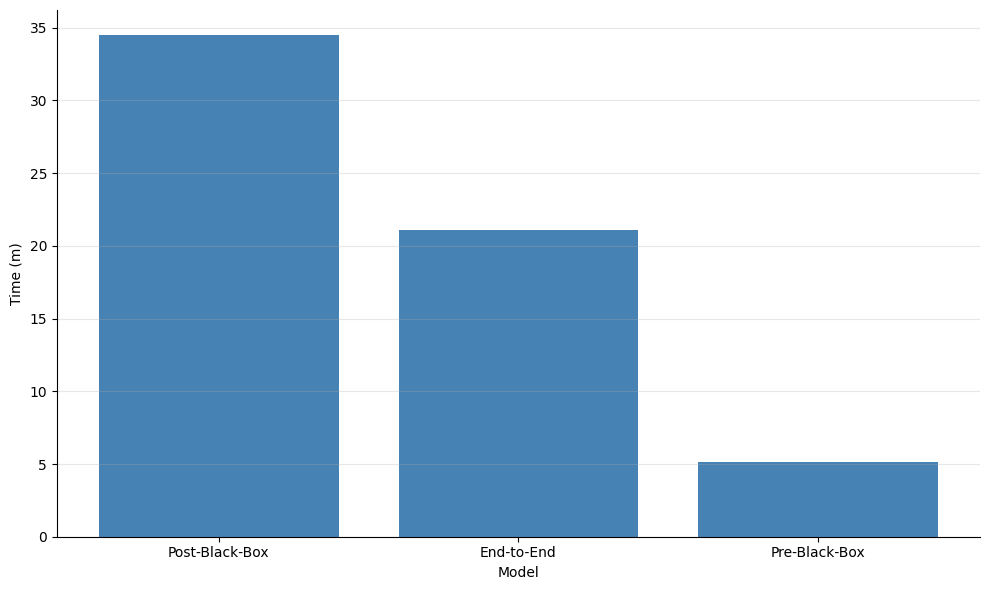

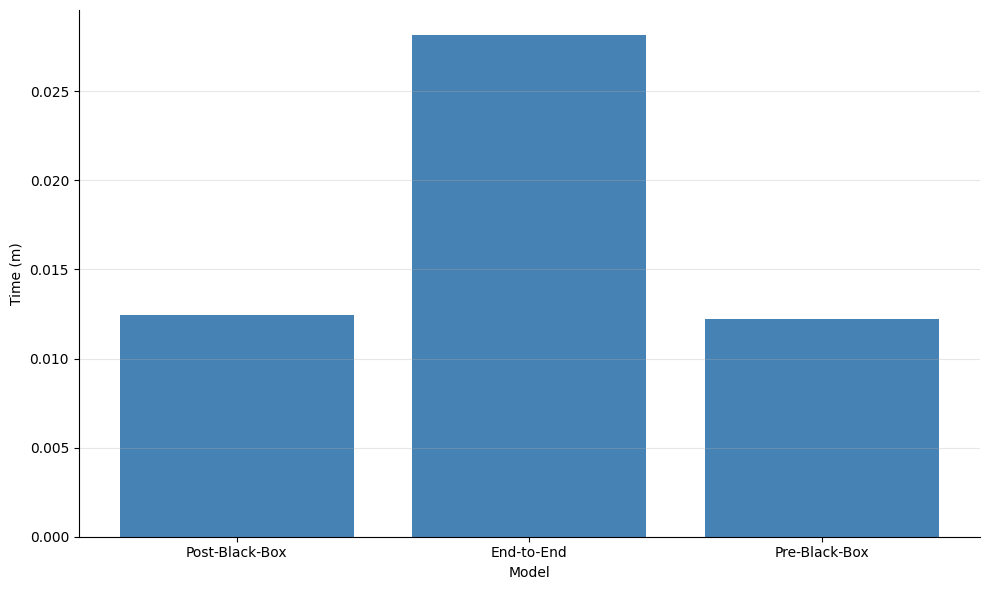

(<Axes: xlabel='Model', ylabel='Time (m)'>,
 '/Users/philippedutranoit/document_ordi/nova/Thesis_Repository/Graphs/Cover_type/Prediction_Time_Comparison.png')

In [26]:
plot_time_comparasion(model_results={"MLP": MLP_training_time,"NAM": NAM_training_time,"Hybrid": Hybrid_training_time},metric="train",save_path=path_graph, save_title="Training_Time_Comparison")

plot_time_comparasion(model_results={"MLP": MLP_prediction_time,"NAM": NAM_prediction_time,"Hybrid": Hybrid_prediction_time},metric="predict",save_path=path_graph, save_title="Prediction_Time_Comparison")


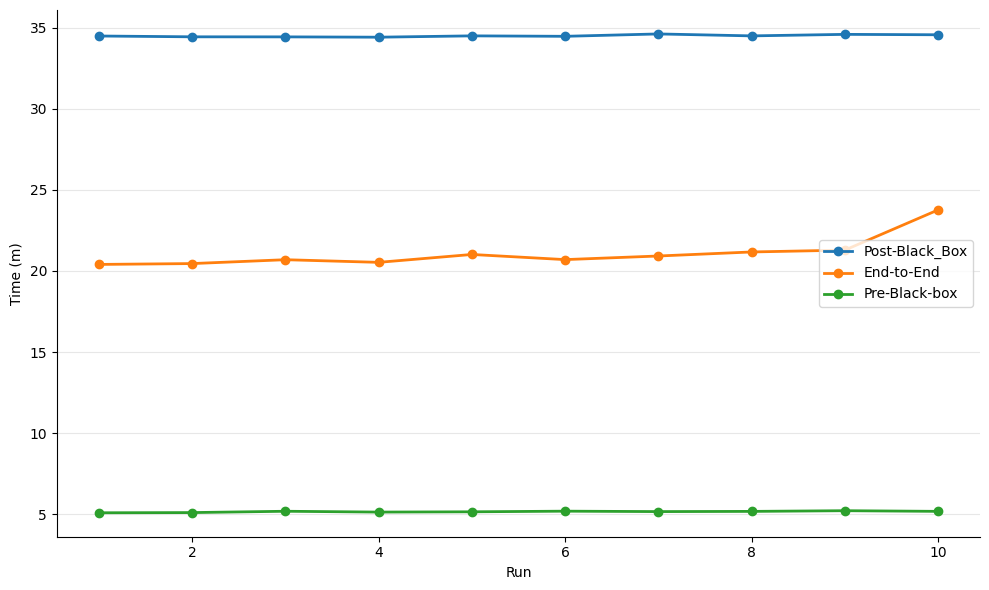

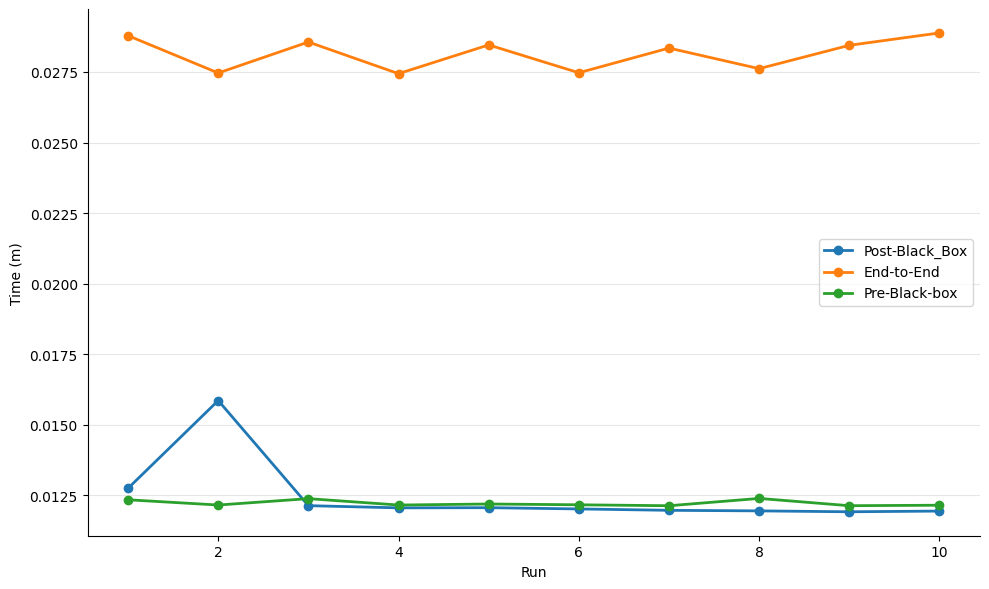

(<Axes: xlabel='Run', ylabel='Time (m)'>,
 '/Users/philippedutranoit/document_ordi/nova/Thesis_Repository/Graphs/Cover_type/Prediction_Time_Curve.png')

In [27]:
plot_time_across_runs(model_results={"MLP": MLP_training_time,"NAM": NAM_training_time,"Hybrid": Hybrid_training_time},metric="train",save_path=path_graph, save_title="Training_Time_Curve")

plot_time_across_runs(model_results={"MLP": MLP_prediction_time,"NAM": NAM_prediction_time,"Hybrid": Hybrid_prediction_time},metric="predict",save_path=path_graph, save_title="Prediction_Time_Curve")

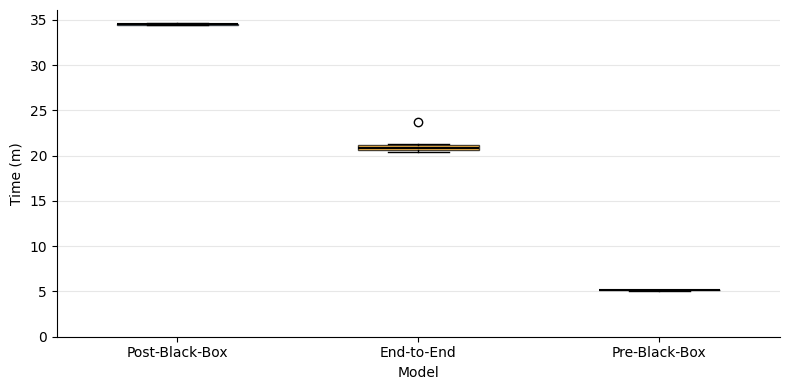

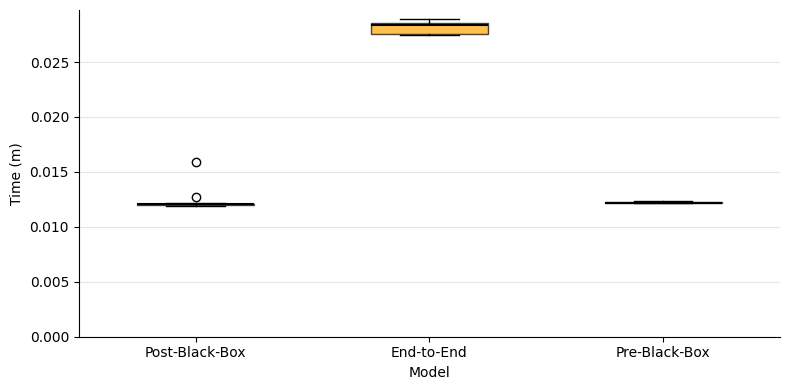

(<Axes: xlabel='Model', ylabel='Time (m)'>,
 '/Users/philippedutranoit/document_ordi/nova/Thesis_Repository/Graphs/Cover_type/Prediction_Time_Boxplot.png')

In [28]:
plot_time_boxplot(
    model_results={
        "MLP": MLP_training_time,
        "NAM": NAM_training_time,
        "Hybrid": Hybrid_training_time
    },
    metric="train",
    save_path= path_graph,
    save_title= "Training_Time_Boxplot"
)


plot_time_boxplot(
    model_results={
        "MLP": MLP_prediction_time,
        "NAM": NAM_prediction_time,
        "Hybrid": Hybrid_prediction_time
    },
    metric="predict",
    save_path= path_graph,
    save_title= "Prediction_Time_Boxplot"
)

In [29]:
results_df["train_time_mean(s)"] = [
    MLP_training_time["train_time_mean"],
    NAM_training_time["train_time_mean"],
    Hybrid_training_time["train_time_mean"]
]

results_df["train_time_std"] = [
    MLP_training_time["train_time_std"],
    NAM_training_time["train_time_std"],
    Hybrid_training_time["train_time_std"]
]

results_df["predict_time_mean(s)"] = [
    MLP_prediction_time["predict_time_mean"],
    NAM_prediction_time["predict_time_mean"],
    Hybrid_prediction_time["predict_time_mean"]
]

results_df["predict_time_std"] = [
    MLP_prediction_time["predict_time_std"],
    NAM_prediction_time["predict_time_std"],
    Hybrid_prediction_time["predict_time_std"]
]

results_df

,Model,accuracy,f1_macro,logloss,train_time_mean(s),train_time_std,predict_time_mean(s),predict_time_std
0,MLP+SHAP,0.907748,0.868365,0.232156,34.497765,0.064681,0.012463,0.001154
1,NAM,0.728013,0.537625,0.619917,21.092202,0.933706,0.028148,0.000552
2,LogReg+MLP,0.847217,0.766024,0.376038,5.155677,0.037879,0.012218,0.000101


<hr>
<a class="anchor" id="setup">

## Performance metrics

In this performance section, we evaluate the models with three complementary metrics: accuracy, macro F1-score, and log loss.

Accuracy gives the overall proportion of correct predictions, so it is a simple first measure of how often the model gets the class right.

The macro F1-score is especially important when the classes are not perfectly balanced. It computes the F1-score for each class separately and then averages them equally, so every class matters the same way even if some classes appear much more often than others.

Log loss measures the quality of the predicted probabilities, not just the final class label. It penalizes confident wrong predictions more heavily, which makes it useful for checking whether the model is well calibrated and truly informative in its probability estimates.

Together, these metrics give a more complete view of performance: accuracy shows overall correctness, macro F1-score captures balanced class-wise behavior, and log loss evaluates probabilistic confidence.

In [11]:
mlp_metrics = compute_performance_metrics(
    y_true=y_test,
    predict_fn=lambda: [
        bb_model_1.predict(X_test, verbose=0),
        bb_model_2.predict(X_test, verbose=0),
        bb_model_3.predict(X_test, verbose=0),
        bb_model_4.predict(X_test, verbose=0),
        bb_model_5.predict(X_test, verbose=0),
    ],
    model_name="MLP+SHAP"
)

nam_metrics = compute_performance_metrics(
    y_true=y_test,
    predict_fn=lambda: [
        nam_model_1.predict(X_test, verbose=0),
        nam_model_2.predict(X_test, verbose=0),
        nam_model_3.predict(X_test, verbose=0),
        nam_model_4.predict(X_test, verbose=0),
        nam_model_5.predict(X_test, verbose=0),
    ],
    model_name="NAM"

)

hybrid_metrics = compute_performance_metrics(
    y_true=y_test,
    predict_fn=lambda: [
        hybrid_predict(logreg_model_1, MLP_hybrid_1, X_test, tau=hybrid_tau)[0],
        hybrid_predict(logreg_model_2, MLP_hybrid_2, X_test, tau=hybrid_tau)[0],
        hybrid_predict(logreg_model_3, MLP_hybrid_3, X_test, tau=hybrid_tau)[0],
        hybrid_predict(logreg_model_4, MLP_hybrid_4, X_test, tau=hybrid_tau)[0],
        hybrid_predict(logreg_model_5, MLP_hybrid_5, X_test, tau=hybrid_tau)[0],
    ],
    model_name="LogReg+MLP"
)

MLP+SHAP Performance Metrics:
  Accuracy: 0.9042 ± 0.0034
  F1 (macro): 0.8628 ± 0.0070
  Log-loss: 0.2401 ± 0.0080
NAM Performance Metrics:
  Accuracy: 0.7297 ± 0.0007
  F1 (macro): 0.5466 ± 0.0147
  Log-loss: 0.6159 ± 0.0031
LogReg+MLP Performance Metrics:
  Accuracy: 0.8497 ± 0.0062
  F1 (macro): 0.7677 ± 0.0120
  Log-loss: 0.3689 ± 0.0100


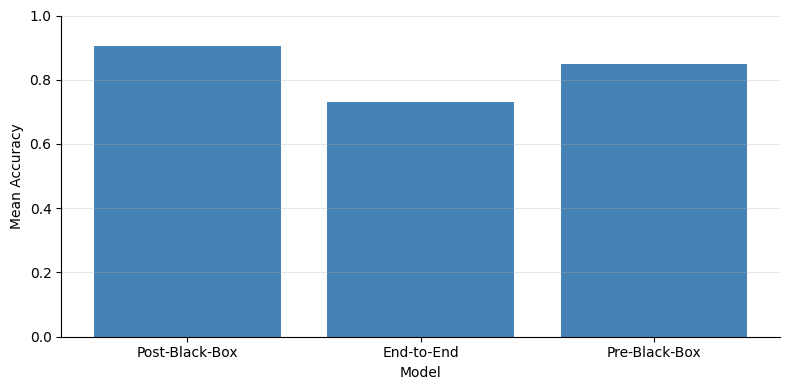

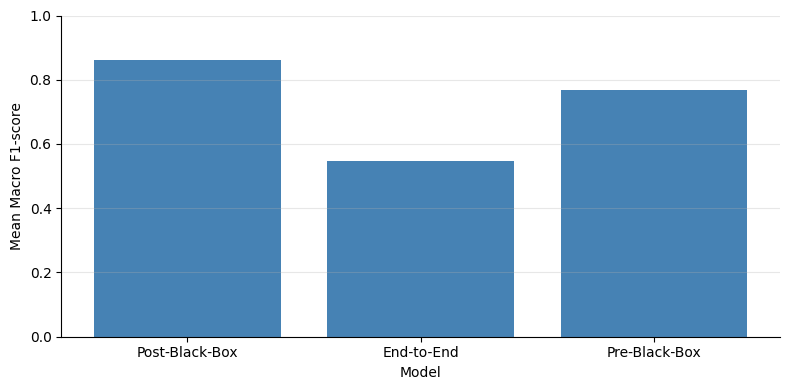

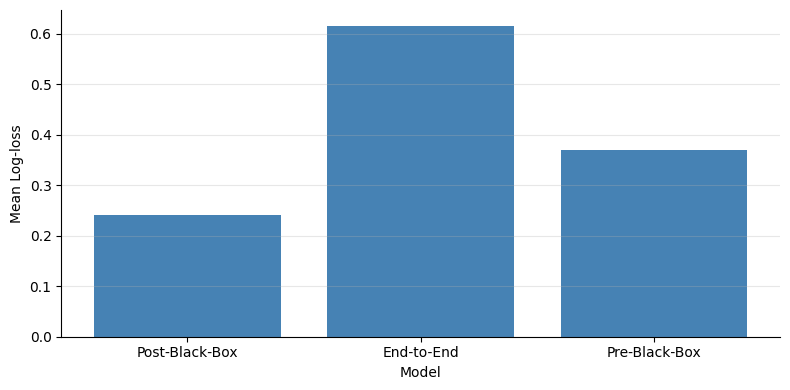

(<Axes: xlabel='Model', ylabel='Mean Log-loss'>,
 'Graphs/Cover_type/Log_Loss_Comparison.png')

In [12]:
plot_performance_metric_comparison(
    mlp_metrics,
    nam_metrics,
    hybrid_metrics,
    metric="accuracy",
    save_path=path_graph,
    save_title="Accuracy_Comparison"
)

plot_performance_metric_comparison(
    mlp_metrics,
    nam_metrics,
    hybrid_metrics,
    metric="f1_macro",
    save_path=path_graph,
    save_title="F1_Macro_Comparison"
)


plot_performance_metric_comparison(
    mlp_metrics,
    nam_metrics,
    hybrid_metrics,
    metric="logloss",
    save_path=path_graph,
    save_title="Log_Loss_Comparison"

)

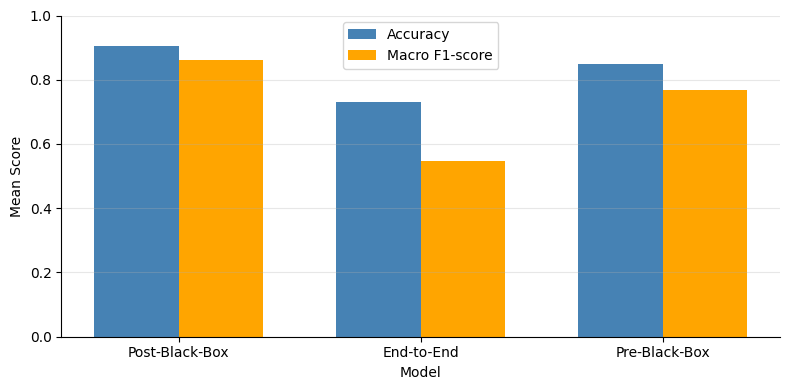

(<Axes: xlabel='Model', ylabel='Mean Score'>,
 'Graphs/Cover_type/Performance_Summary.png')

In [13]:
plot_performance_summary(
    mlp_metrics,
    nam_metrics,
    hybrid_metrics,
    figsize=(8, 4),
    save_path=path_graph,
    save_title="Performance_Summary"
)

In [14]:
results_df["accuracy_mean"] = [
    mlp_metrics["accuracy"],
    nam_metrics["accuracy"],
    hybrid_metrics["accuracy"]
]

results_df["accuracy_std"] = [
    mlp_metrics["accuracy_sd"],
    nam_metrics["accuracy_sd"],
    hybrid_metrics["accuracy_sd"]
]

results_df["f1_macro_mean"] = [
    mlp_metrics["f1_macro"],
    nam_metrics["f1_macro"],
    hybrid_metrics["f1_macro"]
]

results_df["f1_macro_std"] = [
    mlp_metrics["f1_macro_sd"],
    nam_metrics["f1_macro_sd"],
    hybrid_metrics["f1_macro_sd"]
]

results_df["logloss_mean"] = [
    mlp_metrics["logloss"],
    nam_metrics["logloss"],
    hybrid_metrics["logloss"]
]

results_df["logloss_std"] = [
    mlp_metrics["logloss_sd"],
    nam_metrics["logloss_sd"],
    hybrid_metrics["logloss_sd"]
]

results_df

,Model,train_time_mean(s),train_time_std,predict_time_mean(s),predict_time_std,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,logloss_mean,logloss_std
0,MLP+SHAP,34.497765,0.064681,0.012463,0.001154,0.904158,0.003426,0.862805,0.007016,0.240147,0.007981
1,NAM,21.092202,0.933706,0.028148,0.000552,0.729713,0.000654,0.546565,0.014650,0.615884,0.003076
2,LogReg+MLP,5.155677,0.037879,0.012218,0.000101,0.849723,0.006166,0.767725,0.011974,0.368926,0.010019


<hr>
<a class="anchor" id="setup">

## Overfitting

In this section, we evaluate overfitting by comparing each model's performance on the training data and the validation data. The goal is to determine whether the model learns patterns that generalize well, or whether it fits too closely to the training set.

Instead of relying on learning-curve plots, overfitting is assessed through train-validation performance gaps. For each model, we compare the training and validation accuracy, as well as the training and validation loss. The accuracy overfitting gap is defined as the difference between training accuracy and validation accuracy, while the loss overfitting gap compares the validation loss with the training loss.

A larger positive accuracy gap indicates that the model performs better on the training data than on unseen validation data, which suggests weaker generalization. Similarly, a larger positive loss gap indicates that the model makes less reliable predictions on the validation set than on the training set.

For the neural-network-based models, these metrics are computed using the best epoch identified during training. For the hybrid model, overfitting is evaluated using the complete hybrid decision rule. This means that Logistic Regression is used when its confidence is above the selected threshold, while the MLP is used for less confident cases.

Since each model type is trained across multiple runs, the reported overfitting metrics are summarized using the mean and standard deviation across runs. The mean indicates the average degree of overfitting, while the standard deviation shows how stable this behavior is across different training runs.

Overall, lower train-validation gaps indicate better generalization, while higher gaps suggest that the model may rely more strongly on patterns specific to the training data.

In [15]:
mlp_overfit = compute_overfitting_metrics_repeated([
    mlp_history_1,
    mlp_history_2,
    mlp_history_3,
    mlp_history_4,
    mlp_history_5,
])

nam_overfit = compute_overfitting_metrics_repeated([
    nam_history_1,
    nam_history_2,
    nam_history_3,
    nam_history_4,
    nam_history_5,
])

hybrid_overfit = compute_hybrid_overfitting_gap_repeated(
    logreg_model_list=[
        logreg_model_1,
        logreg_model_2,
        logreg_model_3,
        logreg_model_4,
        logreg_model_5,
    ],
    MLP_hybrid_list=[
        MLP_hybrid_1,
        MLP_hybrid_2,
        MLP_hybrid_3,
        MLP_hybrid_4,
        MLP_hybrid_5,
    ],
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    tau=hybrid_tau
)

print("MLP accuracy mean gap:", mlp_overfit["accuracy_overfitting_gap"])
print("MLP accuracy gap SD:", mlp_overfit["accuracy_overfitting_gap_sd"])

print("NAM accuracy mean gap:", nam_overfit["accuracy_overfitting_gap"])
print("NAM accuracy gap SD:", nam_overfit["accuracy_overfitting_gap_sd"])

print("Hybrid accuracy mean gap:", hybrid_overfit["accuracy_overfitting_gap"])
print("Hybrid accuracy gap SD:", hybrid_overfit["accuracy_overfitting_gap_sd"])

MLP accuracy mean gap: -0.02276155948638916
MLP accuracy gap SD: 0.0018345185459227805
NAM accuracy mean gap: 6.740093231201172e-05
NAM accuracy gap SD: 0.00034496518987259863
Hybrid accuracy mean gap: 0.002914459467212316
Hybrid accuracy gap SD: 0.0005134986111996978


In [16]:
results_df["accuracy_overfitting_gap_mean"] = [
    mlp_overfit["accuracy_overfitting_gap_mean"],
    nam_overfit["accuracy_overfitting_gap_mean"],
    hybrid_overfit["accuracy_overfitting_gap_mean"]
]

results_df["accuracy_overfitting_gap_sd"] = [
    mlp_overfit["accuracy_overfitting_gap_sd"],
    nam_overfit["accuracy_overfitting_gap_sd"],
    hybrid_overfit["accuracy_overfitting_gap_sd"]
]

results_df["loss_overfitting_gap_mean"] = [
    mlp_overfit["loss_overfitting_gap_mean"],
    nam_overfit["loss_overfitting_gap_mean"],
    hybrid_overfit["logloss_overfitting_gap_mean"]
]

results_df["loss_overfitting_gap_sd"] = [
    mlp_overfit["loss_overfitting_gap_sd"],
    nam_overfit["loss_overfitting_gap_sd"],
    hybrid_overfit["logloss_overfitting_gap_sd"]
]

results_df

,Model,train_time_mean(s),train_time_std,predict_time_mean(s),predict_time_std,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,logloss_mean,logloss_std,accuracy_overfitting_gap_mean,accuracy_overfitting_gap_sd,loss_overfitting_gap_mean,loss_overfitting_gap_sd
0,MLP+SHAP,34.497765,0.064681,0.012463,0.001154,0.904158,0.003426,0.862805,0.007016,0.240147,0.007981,-0.022762,0.001835,-0.047660,0.002392
1,NAM,21.092202,0.933706,0.028148,0.000552,0.729713,0.000654,0.546565,0.014650,0.615884,0.003076,0.000067,0.000345,0.000423,0.000177
2,LogReg+MLP,5.155677,0.037879,0.012218,0.000101,0.849723,0.006166,0.767725,0.011974,0.368926,0.010019,0.002914,0.000513,0.006738,0.000168


<hr>
<a class="anchor" id="setup">

## Faithfulness

In this section, we compute faithfulness with a deletion-based protocol. The goal is to test whether features ranked as important by the explanation are truly important for the model’s prediction.

For each sample, we first compute a local ranking of features from the contribution tensor. Then, we progressively remove the top-ranked features one by one by replacing them with a baseline value built from the training data: mean for numerical features and mode for categorical/one-hot features.

After each deletion step $k$, we run the model again and track the confidence on the sample’s original predicted class. This gives a confidence curve and a corresponding drop curve (original confidence minus perturbed confidence).

The final faithfulness score is a normalized AOPC-style quantity: we normalize each sample’s drop curve by its final drop (at $k = \text{max\_k}$), clip to $[0,1]$, average over steps, then average across samples. Higher faithfulness means confidence drops earlier and more consistently when the explanation says important features are removed, which indicates better alignment between explanation and model behavior.

In [17]:
faithfulness_pct = 0.25
max_k_faithfulness = int(np.ceil(X_test.shape[1] * faithfulness_pct))

mlp_faith_result = compute_faithfulness_adup_repeated(
    X=X_test,
    contribs_list=[
        contrib_mlp_test_1,
        contrib_mlp_test_2,
        contrib_mlp_test_3,
        contrib_mlp_test_4,
        contrib_mlp_test_5,
    ],
    predict_fn_list=[
        lambda X: bb_model_1.predict(X, verbose=0),
        lambda X: bb_model_2.predict(X, verbose=0),
        lambda X: bb_model_3.predict(X, verbose=0),
        lambda X: bb_model_4.predict(X, verbose=0),
        lambda X: bb_model_5.predict(X, verbose=0),
    ],
    X_train=X_train,
    categorical_mask=categorical_mask,
    max_k=max_k_faithfulness
)

nam_faith_result = compute_faithfulness_adup_repeated(
    X=X_test,
    contribs_list=[
        contrib_nam_test_1,
        contrib_nam_test_2,
        contrib_nam_test_3,
        contrib_nam_test_4,
        contrib_nam_test_5,
    ],
    predict_fn_list=[
        lambda X: nam_model_1.predict(X, verbose=0),
        lambda X: nam_model_2.predict(X, verbose=0),
        lambda X: nam_model_3.predict(X, verbose=0),
        lambda X: nam_model_4.predict(X, verbose=0),
        lambda X: nam_model_5.predict(X, verbose=0),
    ],
    X_train=X_train,
    categorical_mask=categorical_mask,
    max_k=max_k_faithfulness
)


hybrid_faith_result = compute_faithfulness_adup_repeated(
    X=X_test,
    contribs_list=[hybrid_contrib_test_1, hybrid_contrib_test_2, hybrid_contrib_test_3, hybrid_contrib_test_4, hybrid_contrib_test_5 ],
    predict_fn_list=[
        lambda X: hybrid_predict(logreg_model_1, MLP_hybrid_1, X, tau=hybrid_tau)[0],
        lambda X: hybrid_predict(logreg_model_2, MLP_hybrid_2, X, tau=hybrid_tau)[0],
        lambda X: hybrid_predict(logreg_model_3, MLP_hybrid_3, X, tau=hybrid_tau)[0],
        lambda X: hybrid_predict(logreg_model_4, MLP_hybrid_4, X, tau=hybrid_tau)[0],
        lambda X: hybrid_predict(logreg_model_5, MLP_hybrid_5, X, tau=hybrid_tau)[0],
    ],
    X_train=X_train,
    categorical_mask=categorical_mask,
    max_k=max_k_faithfulness
)

print("MLP Mean Faithfulness:", mlp_faith_result["faithfulness"])
print("NAM Mean Faithfulness:", nam_faith_result["faithfulness"])
print("Hybrid Mean Faithfulness:", hybrid_faith_result["faithfulness"])

print("MLP Standard Deviation of Faithfulness:", mlp_faith_result["faithfulness_sd"])
print("NAM Standard Deviation of Faithfulness:", nam_faith_result["faithfulness_sd"])
print("Hybrid Standard Deviation of Faithfulness:", hybrid_faith_result["faithfulness_sd"])

all_results = {
    "MLP": mlp_faith_result,
    "NAM": nam_faith_result,
    "Hybrid": hybrid_faith_result
}

MLP Mean Faithfulness: 0.8061553001403808
NAM Mean Faithfulness: 0.6750259041786194
Hybrid Mean Faithfulness: 0.7289319515228272
MLP Standard Deviation of Faithfulness: 0.017802984259883796
NAM Standard Deviation of Faithfulness: 0.014512259777633367
Hybrid Standard Deviation of Faithfulness: 0.033650391089093235


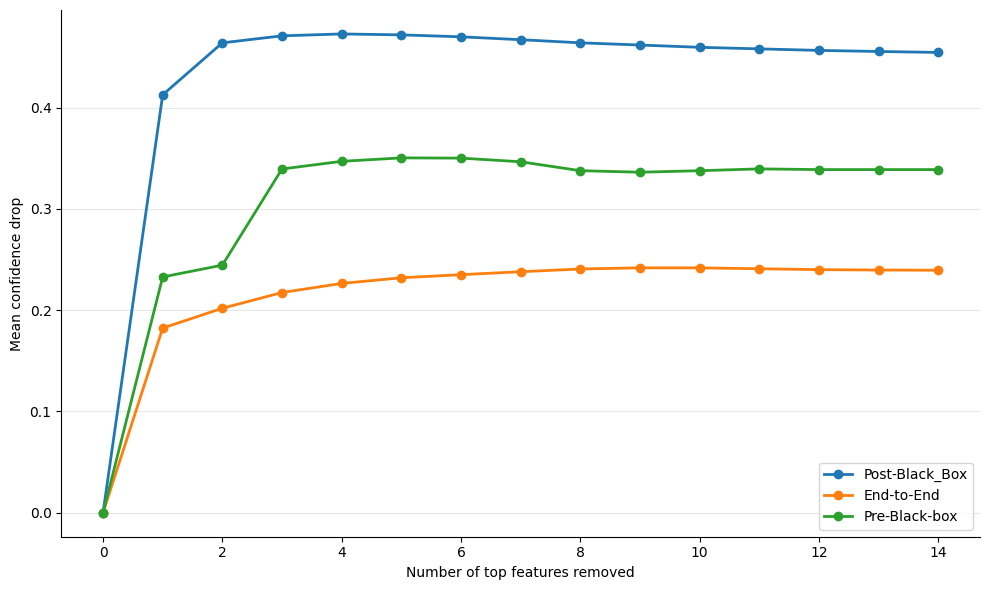

(<Axes: xlabel='Number of top features removed', ylabel='Mean confidence drop'>,
 'Graphs/Cover_type/Faithfulness_Mean_drop_Curve.png')

In [18]:
plot_faithfulness_curves(
    results_dict=all_results,
    curve_key="mean_drop_curve",
    ylabel="Mean confidence drop",
    save_path=path_graph,
    save_title="Faithfulness_Mean_drop_Curve"
)

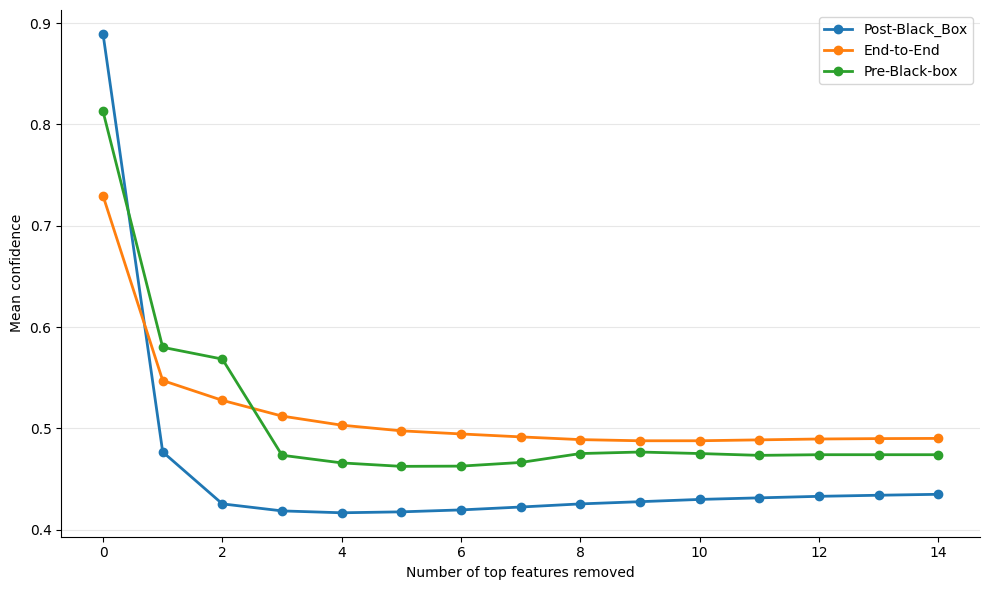

(<Axes: xlabel='Number of top features removed', ylabel='Mean confidence'>,
 'Graphs/Cover_type/Faithfulness_Mean_Confidence_Curve.png')

In [19]:
plot_faithfulness_curves(
    results_dict=all_results,
    curve_key="mean_conf_curve",
    ylabel="Mean confidence",
    save_path=path_graph,
    save_title="Faithfulness_Mean_Confidence_Curve"
)

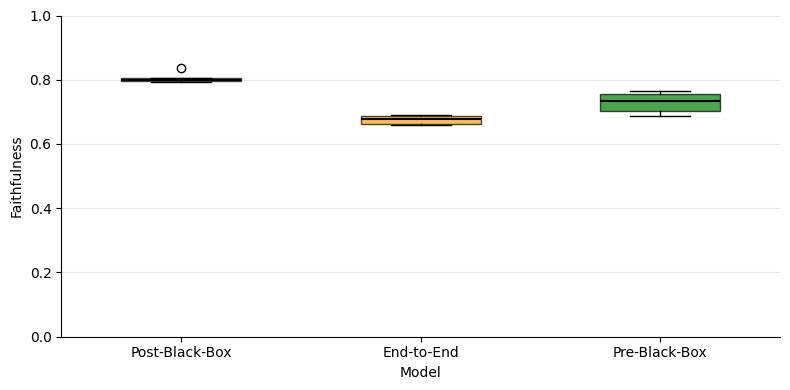

(<Axes: xlabel='Model', ylabel='Faithfulness'>, None)

In [20]:
plot_faithfulness_boxplot(
    mlp_faith_result,
    nam_faith_result,
    hybrid_faith_result,
    save_path=None,
    save_title="faithfulness_boxplot"
)

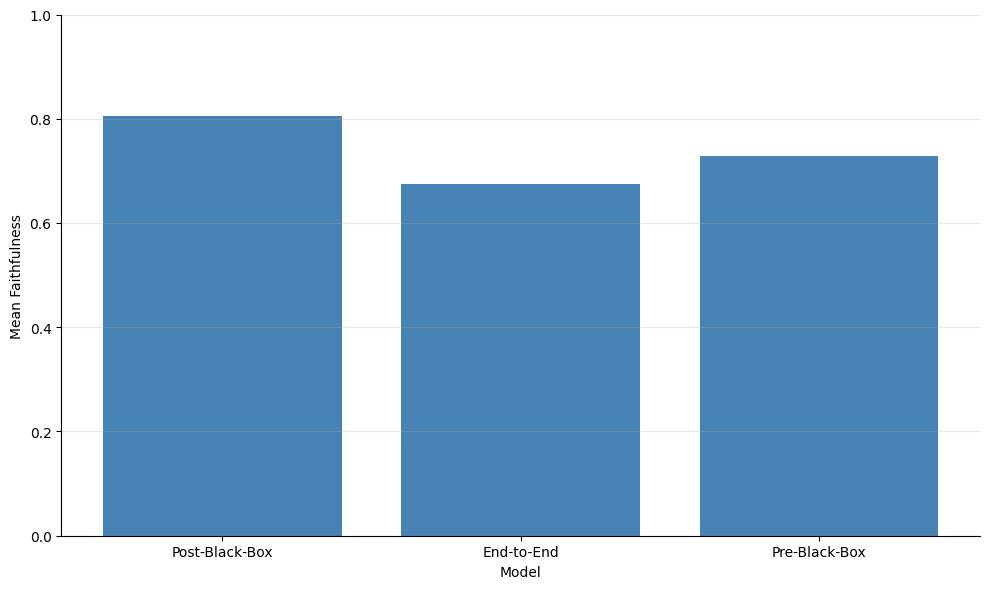

(<Axes: xlabel='Model', ylabel='Mean Faithfulness'>,
 'Graphs/Cover_type/Faithfulness_Comparison.png')

In [21]:
plot_faithfulness_comparison(
    mlp_faith_result,
    nam_faith_result,
    hybrid_faith_result,
    figsize=(10, 6),
    save_path=path_graph,
    save_title="Faithfulness_Comparison"
)

In [22]:
results_df["faithfulness_mean"] = [
    mlp_faith_result["faithfulness"],
    nam_faith_result["faithfulness"],
    hybrid_faith_result["faithfulness"]
]

results_df["faithfulness_std"] = [
    mlp_faith_result["faithfulness_sd"],
    nam_faith_result["faithfulness_sd"],
    hybrid_faith_result["faithfulness_sd"]
]

results_df

,Model,train_time_mean(s),train_time_std,predict_time_mean(s),predict_time_std,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,logloss_mean,logloss_std,accuracy_overfitting_gap_mean,accuracy_overfitting_gap_sd,loss_overfitting_gap_mean,loss_overfitting_gap_sd,faithfulness_mean,faithfulness_std
0,MLP+SHAP,34.497765,0.064681,0.012463,0.001154,0.904158,0.003426,0.862805,0.007016,0.240147,0.007981,-0.022762,0.001835,-0.047660,0.002392,0.806155,0.017803
1,NAM,21.092202,0.933706,0.028148,0.000552,0.729713,0.000654,0.546565,0.014650,0.615884,0.003076,0.000067,0.000345,0.000423,0.000177,0.675026,0.014512
2,LogReg+MLP,5.155677,0.037879,0.012218,0.000101,0.849723,0.006166,0.767725,0.011974,0.368926,0.010019,0.002914,0.000513,0.006738,0.000168,0.728932,0.033650


<hr>
<a class="anchor" id="setup">

## Stability

In this section, we compute stability by measuring how consistent the explanation scores remain under small input perturbations. The goal is to test whether similar inputs receive similar explanations, which indicates that the explanation method is robust to local changes in the data.

For each sample, we first compute the original explanation from the contribution tensor. Then, we create several slightly perturbed versions of the same input by adding small noise to numerical features and randomly changing categorical one-hot groups with a low probability.

After each perturbation, we recompute the explanation and compare it with the original one using Spearman correlation. This gives a stability score for each perturbed sample, which we then average across perturbations and across samples.

The final stability score is the mean Spearman correlation between the original and perturbed explanations. Higher stability means the explanation changes less when the input is slightly modified, which indicates better robustness and reliability of the explanation method.

In [ ]:
def explain_fn_mlp_1(X_input):
    return get_mlp_shap_contributions(bb_model_1, X_train, X_input, n_background=200)
def explain_fn_mlp_2(X_input):
    return get_mlp_shap_contributions(bb_model_2, X_train, X_input, n_background=200)
def explain_fn_mlp_3(X_input):
    return get_mlp_shap_contributions(bb_model_3, X_train, X_input, n_background=200)
def explain_fn_mlp_4(X_input):
    return get_mlp_shap_contributions(bb_model_4, X_train, X_input, n_background=200)
def explain_fn_mlp_5(X_input):
    return get_mlp_shap_contributions(bb_model_5, X_train, X_input, n_background=200)

def explain_fn_nam_1(X_input):
    return get_nam_contributions(nam_contribs_1, X_input)
def explain_fn_nam_2(X_input):
    return get_nam_contributions(nam_contribs_2, X_input)
def explain_fn_nam_3(X_input):
    return get_nam_contributions(nam_contribs_3, X_input)
def explain_fn_nam_4(X_input):
    return get_nam_contributions(nam_contribs_4, X_input)
def explain_fn_nam_5(X_input):
    return get_nam_contributions(nam_contribs_5, X_input)

def explain_fn_hybrid_1(X_input):
    return get_logreg_contributions(logreg_model_1, X_test)
def explain_fn_hybrid_2(X_input):
    return get_logreg_contributions(logreg_model_2, X_test)
def explain_fn_hybrid_3(X_input):
    return get_logreg_contributions(logreg_model_3, X_test)
def explain_fn_hybrid_4(X_input):
    return get_logreg_contributions(logreg_model_4, X_test)
def explain_fn_hybrid_5(X_input):
    return get_logreg_contributions(logreg_model_5, X_test)


In [24]:
mlp_stability_result = compute_stability_repeated(
    X=X_test,
    contribs_list=[
        contrib_mlp_test_1,
        contrib_mlp_test_2,
        contrib_mlp_test_3,
        contrib_mlp_test_4,
        contrib_mlp_test_5,
    ],
    explain_fn_list=[
        explain_fn_mlp_1,
        explain_fn_mlp_2,
        explain_fn_mlp_3,
        explain_fn_mlp_4,
        explain_fn_mlp_5,
    ],
    numeric_mask=numeric_mask,
    categorical_groups=categorical_groups,
    n_perturbations=10,
    sigma=0.05,
    cat_flip_prob=0.05,
    random_state=42
)

nam_stability_result = compute_stability_repeated(
    X=X_test,
    contribs_list=[
        contrib_nam_test_1,
        contrib_nam_test_2,
        contrib_nam_test_3,
        contrib_nam_test_4,
        contrib_nam_test_5,
    ],
    explain_fn_list=[
        explain_fn_nam_1,
        explain_fn_nam_2,
        explain_fn_nam_3,
        explain_fn_nam_4,
        explain_fn_nam_5,
    ],
    numeric_mask=numeric_mask,
    categorical_groups=categorical_groups,
    n_perturbations=10,
    sigma=0.05,
    cat_flip_prob=0.05,
    random_state=42
)

hybrid_stability_result = compute_stability_repeated(
    X=X_test,
    contribs_list=[hybrid_contrib_test_1, 
                   hybrid_contrib_test_2, 
                   hybrid_contrib_test_3, 
                   hybrid_contrib_test_4, 
                   hybrid_contrib_test_5 ],
    explain_fn_list=[
        explain_fn_hybrid_1,
        explain_fn_hybrid_2,
        explain_fn_hybrid_3,
        explain_fn_hybrid_4,
        explain_fn_hybrid_5,
    ],
    numeric_mask=numeric_mask,
    categorical_groups=categorical_groups,
    n_perturbations=10,
    sigma=0.05,
    cat_flip_prob=0.05,
    random_state=42
)   

print("MLP Mean Stability:", mlp_stability_result["stability"])
print("NAM Mean Stability:", nam_stability_result["stability"])
print("Hybrid Mean Stability:", hybrid_stability_result["stability"])

print("MLP Standard Deviation of Stability:", mlp_stability_result["stability_sd"])
print("NAM Standard Deviation of Stability:", nam_stability_result["stability_sd"])
print("Hybrid Standard Deviation of Stability:", hybrid_stability_result["stability_sd"])

/opt/homebrew/lib/python3.11/site-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: X
Received: inputs=['Tensor(shape=(58102, 54))']
  warnings.warn(msg)
/opt/homebrew/lib/python3.11/site-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: X
Received: inputs=['Tensor(shape=(50, 54))']
  warnings.warn(msg)


done run 1 out of 5
done run 2 out of 5
done run 3 out of 5
done run 4 out of 5
done run 5 out of 5
done run 1 out of 5
done run 2 out of 5
done run 3 out of 5
done run 4 out of 5
done run 5 out of 5
done run 1 out of 5
done run 2 out of 5
done run 3 out of 5
done run 4 out of 5
done run 5 out of 5
MLP Mean Stability: 0.8501454350825112
NAM Mean Stability: 0.9853452178258302
Hybrid Mean Stability: 1.0
MLP Standard Deviation of Stability: 0.003184103999558988
NAM Standard Deviation of Stability: 0.0034478728285474735
Hybrid Standard Deviation of Stability: 0.0


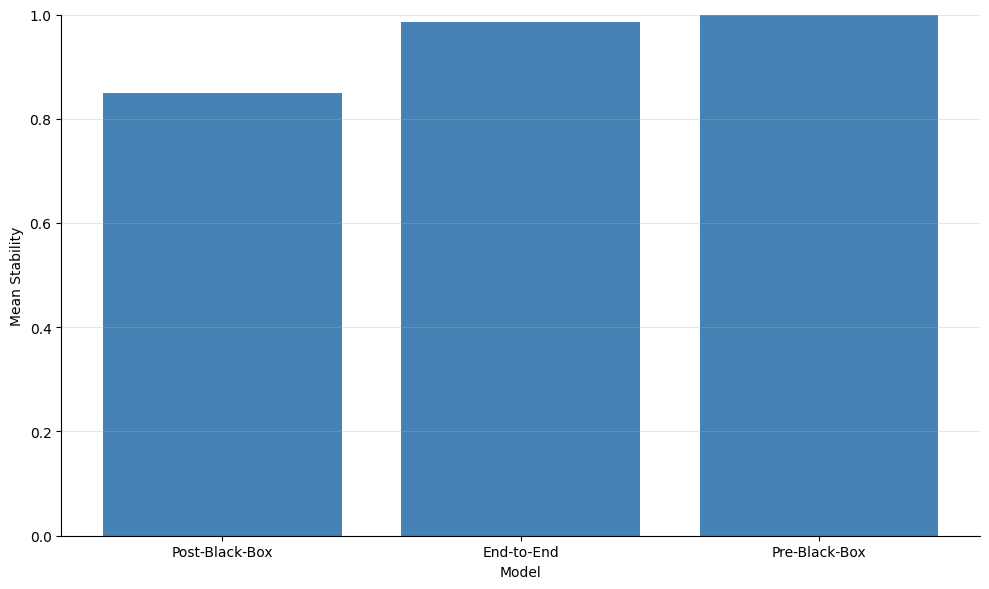

(<Axes: xlabel='Model', ylabel='Mean Stability'>,
 'Graphs/Cover_type/Stability_Comparison.png')

In [25]:
plot_stability_comparison(
    mlp_stability_result,
    nam_stability_result,
    hybrid_stability_result,
    figsize=(10, 6),
    save_path=path_graph,
    save_title="Stability_Comparison"
)


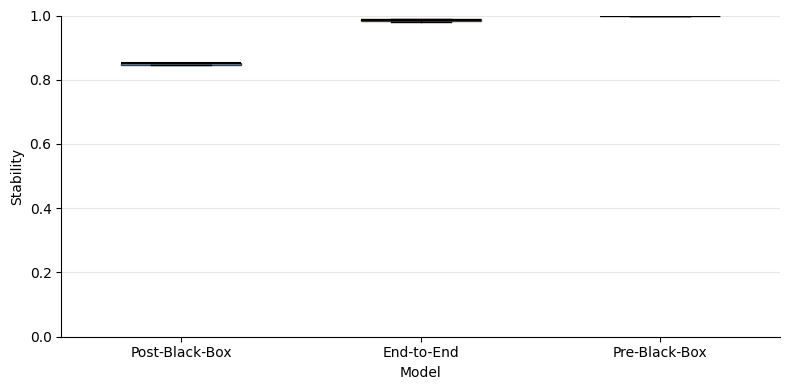

(<Axes: xlabel='Model', ylabel='Stability'>,
 'Graphs/Cover_type/stability_boxplot.png')

In [26]:
plot_stability_boxplot(
    mlp_stability_result,
    nam_stability_result,
    hybrid_stability_result,
    save_path= path_graph,
    save_title="stability_boxplot"
)

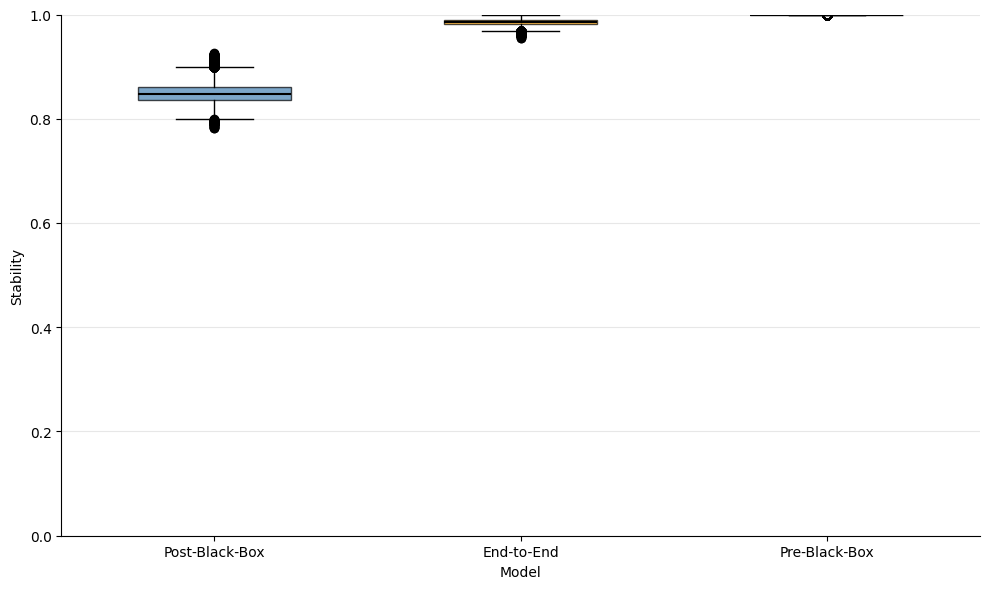

(<Axes: xlabel='Model', ylabel='Stability'>,
 'Graphs/Cover_type/Stability_Per-Sample_Boxplot.png')

In [27]:
plot_metric_boxplot(
    mlp_stability_result["per_sample_stability"],
    nam_stability_result["per_sample_stability"],
    hybrid_stability_result["per_sample_stability"],
    ylabel="Stability",
    save_path=path_graph,
    save_title="Stability_Per-Sample_Boxplot"
)

In [28]:
results_df["stability_mean"] = [
    mlp_stability_result["stability"],
    nam_stability_result["stability"],
    hybrid_stability_result["stability"]
]

results_df["stability_std"] = [
    mlp_stability_result["stability_sd"],
    nam_stability_result["stability_sd"],
    hybrid_stability_result["stability_sd"]
]
results_df

,Model,train_time_mean(s),train_time_std,predict_time_mean(s),predict_time_std,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,logloss_mean,logloss_std,accuracy_overfitting_gap_mean,accuracy_overfitting_gap_sd,loss_overfitting_gap_mean,loss_overfitting_gap_sd,faithfulness_mean,faithfulness_std,stability_mean,stability_std
0,MLP+SHAP,34.497765,0.064681,0.012463,0.001154,0.904158,0.003426,0.862805,0.007016,0.240147,0.007981,-0.022762,0.001835,-0.047660,0.002392,0.806155,0.017803,0.850145,0.003184
1,NAM,21.092202,0.933706,0.028148,0.000552,0.729713,0.000654,0.546565,0.014650,0.615884,0.003076,0.000067,0.000345,0.000423,0.000177,0.675026,0.014512,0.985345,0.003448
2,LogReg+MLP,5.155677,0.037879,0.012218,0.000101,0.849723,0.006166,0.767725,0.011974,0.368926,0.010019,0.002914,0.000513,0.006738,0.000168,0.728932,0.033650,1.000000,0.000000


<hr>
<a class="anchor" id="setup">

## Sparsity

In this section, we compute sparsity to measure how concentrated the explanations are across the input features. The goal is to see whether the model relies on a small number of important features or spreads importance more broadly across many features.

For each sample, we examine the contribution tensor and identify how many feature contributions are effectively close to zero under a fixed threshold. This gives a local sparsity score that reflects how compact the explanation is for each individual prediction.

We then average these local values across all samples to obtain the mean sparsity score. In addition, we compute global sparsity from aggregated feature importance, which captures how concentrated the explanation is at the model level.

The final sparsity analysis therefore reports both mean sparsity and global sparsity. Higher sparsity means that fewer features carry most of the explanatory signal, which makes the explanation easier to interpret and more concise.

In [29]:
mlp_sparsity_result = compute_sparsity_repeated([
    contrib_mlp_test_1,
    contrib_mlp_test_2,
    contrib_mlp_test_3,
    contrib_mlp_test_4,
    contrib_mlp_test_5,
])

print("Local sparsity:", mlp_sparsity_result["sparsity"])
print("Local sparsity SD:", mlp_sparsity_result["sparsity_sd"])
print("Global sparsity:", mlp_sparsity_result["global_sparsity"])
print("Global sparsity SD:", mlp_sparsity_result["global_sparsity_sd"])

nam_sparsity_result = compute_sparsity_repeated([
    contrib_nam_test_1,
    contrib_nam_test_2,
    contrib_nam_test_3,
    contrib_nam_test_4,
    contrib_nam_test_5,
])

print("Local sparsity:", nam_sparsity_result["sparsity"])
print("Local sparsity SD:", nam_sparsity_result["sparsity_sd"])
print("Global sparsity:", nam_sparsity_result["global_sparsity"])
print("Global sparsity SD:", nam_sparsity_result["global_sparsity_sd"])

hybrid_sparsity_result = compute_sparsity_repeated([
    hybrid_contrib_test_1,
    hybrid_contrib_test_2,
    hybrid_contrib_test_3,
    hybrid_contrib_test_4,
    hybrid_contrib_test_5,
])

print("Local sparsity:", hybrid_sparsity_result["sparsity"])
print("Local sparsity SD:", hybrid_sparsity_result["sparsity_sd"])
print("Global sparsity:", hybrid_sparsity_result["global_sparsity"])
print("Global sparsity SD:", hybrid_sparsity_result["global_sparsity_sd"])

Local sparsity: 0.6756633793563093
Local sparsity SD: 0.004614536354858397
Global sparsity: 0.584010332904038
Global sparsity SD: 0.009389623572954624
Local sparsity: 0.6715765963110366
Local sparsity SD: 0.027346235661246294
Global sparsity: 0.659533133661139
Global sparsity SD: 0.034438672227438426
Local sparsity: 0.8488815817668314
Local sparsity SD: 0.0
Global sparsity: 0.8464785167523289
Global sparsity SD: 1.2412670766236366e-16


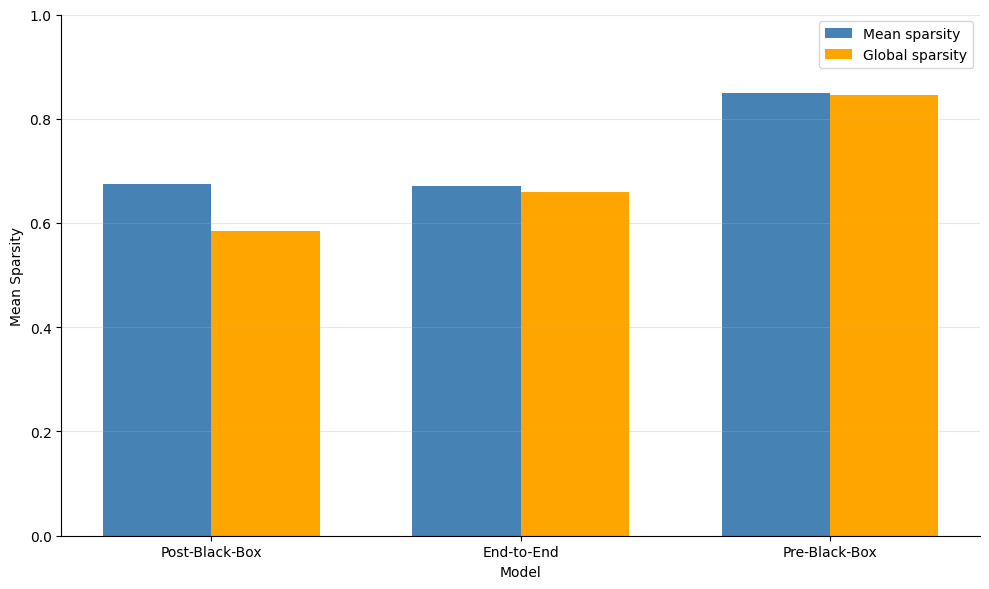

(<Axes: xlabel='Model', ylabel='Mean Sparsity'>,
 'Graphs/Cover_type/Sparsity_Comparison.png')

In [30]:
plot_sparsity_comparison(
    mlp_sparsity_result,
    nam_sparsity_result,
    hybrid_sparsity_result,
    figsize=(10, 6),
    save_path=path_graph,
    save_title="Sparsity_Comparison"
)

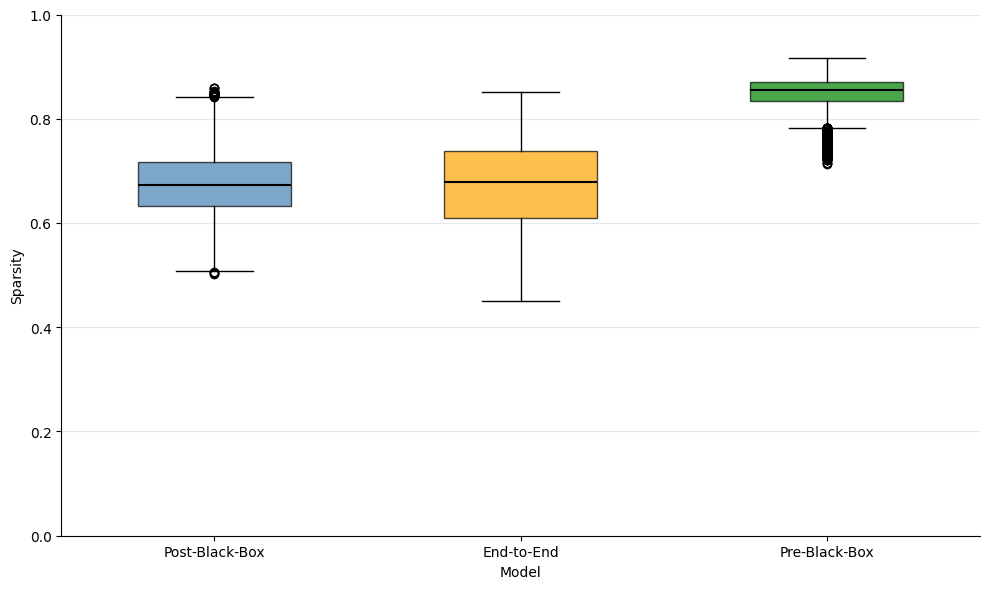

(<Axes: xlabel='Model', ylabel='Sparsity'>,
 'Graphs/Cover_type/Sparsity_Boxplot.png')

In [31]:
plot_metric_boxplot(
    mlp_sparsity_result["per_sample_sparsity"],
    nam_sparsity_result["per_sample_sparsity"],
    hybrid_sparsity_result["per_sample_sparsity"],
    ylabel="Sparsity",
    save_path=path_graph,
    save_title="Sparsity_Boxplot"
)

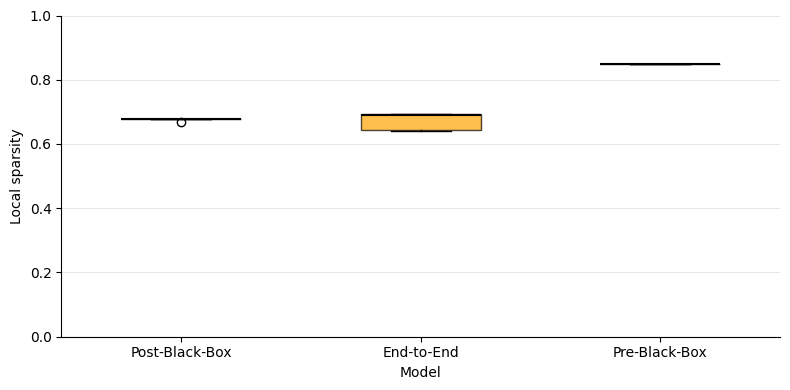

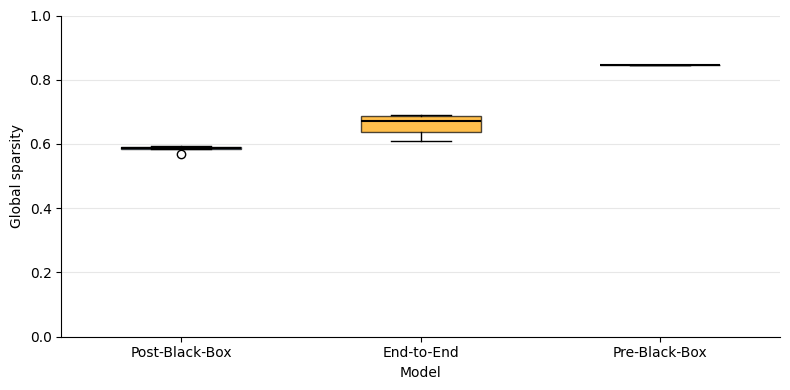

(<Axes: xlabel='Model', ylabel='Global sparsity'>,
 'Graphs/Cover_type/global_sparsity_boxplot.png')

In [32]:
plot_sparsity_boxplot(
    mlp_sparsity_result,
    nam_sparsity_result,
    hybrid_sparsity_result,
    metric="sparsity",
    save_path=path_graph,
    save_title="local_sparsity_boxplot"
)

plot_sparsity_boxplot(
    mlp_sparsity_result,
    nam_sparsity_result,
    hybrid_sparsity_result,
    metric="global_sparsity",
    save_path=path_graph,
    save_title="global_sparsity_boxplot"
)

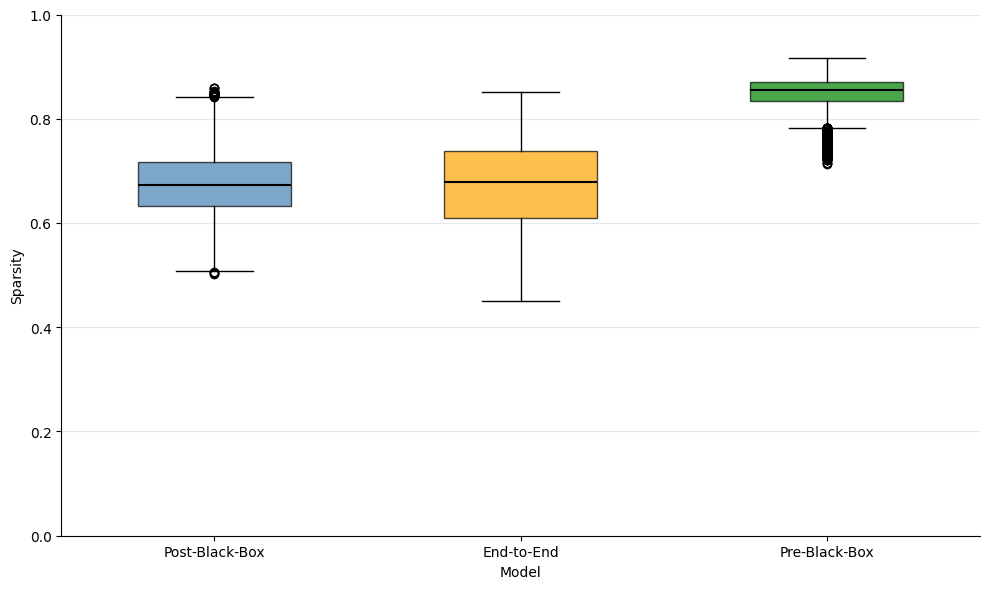

(<Axes: xlabel='Model', ylabel='Sparsity'>,
 'Graphs/Cover_type/Local_Sparsity_Per-Sample_Boxplot.png')

In [33]:
plot_metric_boxplot(
    mlp_sparsity_result["per_sample_sparsity"],
    nam_sparsity_result["per_sample_sparsity"],
    hybrid_sparsity_result["per_sample_sparsity"],
    ylabel="Sparsity",
    save_path=path_graph,
    save_title="Local_Sparsity_Per-Sample_Boxplot"
)

In [34]:
results_df["local_sparsity_mean"] = [
    mlp_sparsity_result["sparsity"],
    nam_sparsity_result["sparsity"],
    hybrid_sparsity_result["sparsity"]
]

results_df["local_sparsity_std"] = [
    mlp_sparsity_result["sparsity_sd"],
    nam_sparsity_result["sparsity_sd"],
    hybrid_sparsity_result["sparsity_sd"]
]

results_df["global_sparsity_mean"] = [
    mlp_sparsity_result["global_sparsity"],
    nam_sparsity_result["global_sparsity"],
    hybrid_sparsity_result["global_sparsity"]
]

results_df["global_sparsity_std"] = [
    mlp_sparsity_result["global_sparsity_sd"],
    nam_sparsity_result["global_sparsity_sd"],
    hybrid_sparsity_result["global_sparsity_sd"]
] 

results_df

,Model,train_time_mean(s),train_time_std,predict_time_mean(s),predict_time_std,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,logloss_mean,...,loss_overfitting_gap_mean,loss_overfitting_gap_sd,faithfulness_mean,faithfulness_std,stability_mean,stability_std,local_sparsity_mean,local_sparsity_std,global_sparsity_mean,global_sparsity_std
0,MLP+SHAP,34.497765,0.064681,0.012463,0.001154,0.904158,0.003426,0.862805,0.007016,0.240147,...,-0.047660,0.002392,0.806155,0.017803,0.850145,0.003184,0.675663,0.004615,0.584010,9.389624e-03
1,NAM,21.092202,0.933706,0.028148,0.000552,0.729713,0.000654,0.546565,0.014650,0.615884,...,0.000423,0.000177,0.675026,0.014512,0.985345,0.003448,0.671577,0.027346,0.659533,3.443867e-02
2,LogReg+MLP,5.155677,0.037879,0.012218,0.000101,0.849723,0.006166,0.767725,0.011974,0.368926,...,0.006738,0.000168,0.728932,0.033650,1.000000,0.000000,0.848882,0.000000,0.846479,1.241267e-16


<hr>
<a class="anchor" id="setup">

## Hybrid transparency

A final aspect that needs to be investigated is the hybrid transparency, also referred to as the pre-black-box transparency rate. Since the hybrid model relies on a gated decision mechanism, some predictions are produced by the transparent Logistic Regression component, while others are passed to the black-box MLP component.

This transparency rate is important because it shows how often the model can make a prediction without relying on the black-box component. In other words, it measures the proportion of cases for which the Logistic Regression model is confident enough to make the final decision on its own. A higher transparency rate means that a larger share of predictions can be explained through the simpler and more interpretable model, while a lower transparency rate means that the hybrid system depends more heavily on the MLP.

To compute this rate, we evaluate the proportion of observations for which the Logistic Regression confidence is above the selected threshold. These observations are handled by the transparent component. The remaining observations, where Logistic Regression confidence is below the threshold, are redirected to the MLP. Therefore, the transparency rate provides a direct indication of the balance between interpretability and predictive complexity in the hybrid model.

In [35]:
hybrid_transparency_rates = []

P_hybrid_test_1, use_logreg_test_1, _ = hybrid_predict(
    logreg_model_1, MLP_hybrid_1, X_test, tau=hybrid_tau
)
hybrid_transparency_rates.append(use_logreg_test_1.mean())

P_hybrid_test_2, use_logreg_test_2, _ = hybrid_predict(
    logreg_model_2, MLP_hybrid_2, X_test, tau=hybrid_tau
)
hybrid_transparency_rates.append(use_logreg_test_2.mean())

P_hybrid_test_3, use_logreg_test_3, _ = hybrid_predict(
    logreg_model_3, MLP_hybrid_3, X_test, tau=hybrid_tau
)
hybrid_transparency_rates.append(use_logreg_test_3.mean())

P_hybrid_test_4, use_logreg_test_4, _ = hybrid_predict(
    logreg_model_4, MLP_hybrid_4, X_test, tau=hybrid_tau
)
hybrid_transparency_rates.append(use_logreg_test_4.mean())

P_hybrid_test_5, use_logreg_test_5, _ = hybrid_predict(
    logreg_model_5, MLP_hybrid_5, X_test, tau=hybrid_tau
)
hybrid_transparency_rates.append(use_logreg_test_5.mean())

hybrid_transparency_rates = np.array(hybrid_transparency_rates)

hybrid_transparency_mean = hybrid_transparency_rates.mean()
hybrid_transparency_sd = hybrid_transparency_rates.std(ddof=1)

print(f"Hybrid transparency: {hybrid_transparency_mean:.3f} ± {hybrid_transparency_sd:.3f}")

Hybrid transparency: 0.071 ± 0.000


In [36]:
results_df["transparency_mean"] = [
    "N/A",
    "N/A",
    hybrid_transparency_mean

]

results_df["transparency_sd"] = [
    "N/A",
    "N/A",
    hybrid_transparency_sd
]

results_df

,Model,train_time_mean(s),train_time_std,predict_time_mean(s),predict_time_std,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,logloss_mean,...,faithfulness_mean,faithfulness_std,stability_mean,stability_std,local_sparsity_mean,local_sparsity_std,global_sparsity_mean,global_sparsity_std,transparency_mean,transparency_sd
0,MLP+SHAP,34.497765,0.064681,0.012463,0.001154,0.904158,0.003426,0.862805,0.007016,0.240147,...,0.806155,0.017803,0.850145,0.003184,0.675663,0.004615,0.584010,9.389624e-03,N/A,N/A
1,NAM,21.092202,0.933706,0.028148,0.000552,0.729713,0.000654,0.546565,0.014650,0.615884,...,0.675026,0.014512,0.985345,0.003448,0.671577,0.027346,0.659533,3.443867e-02,N/A,N/A
2,LogReg+MLP,5.155677,0.037879,0.012218,0.000101,0.849723,0.006166,0.767725,0.011974,0.368926,...,0.728932,0.033650,1.000000,0.000000,0.848882,0.000000,0.846479,1.241267e-16,0.070858,0.0


<hr>
<a class="anchor" id="setup">

# Results

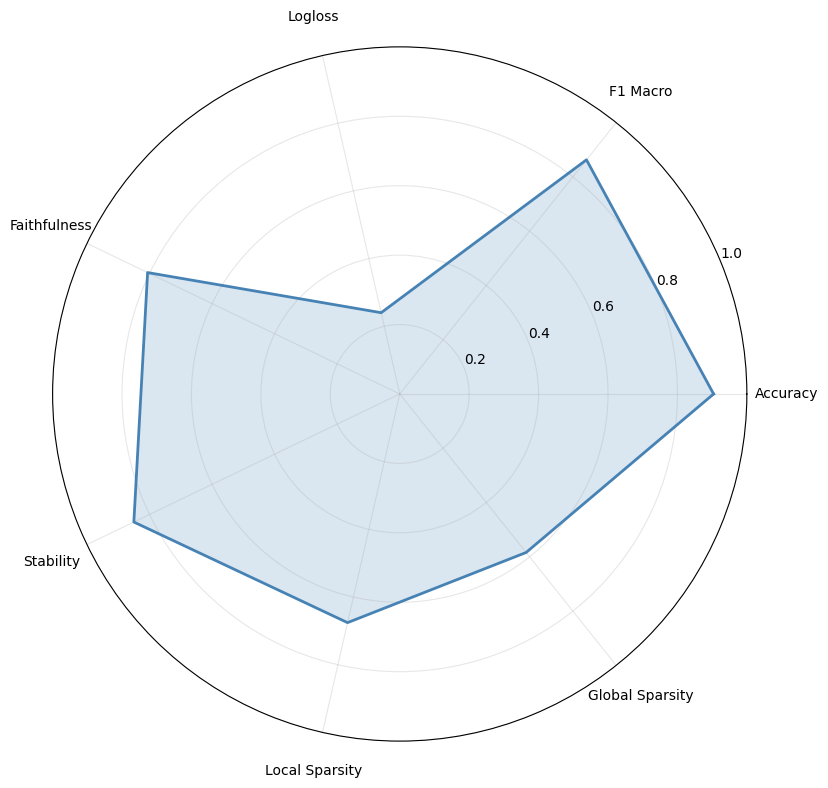

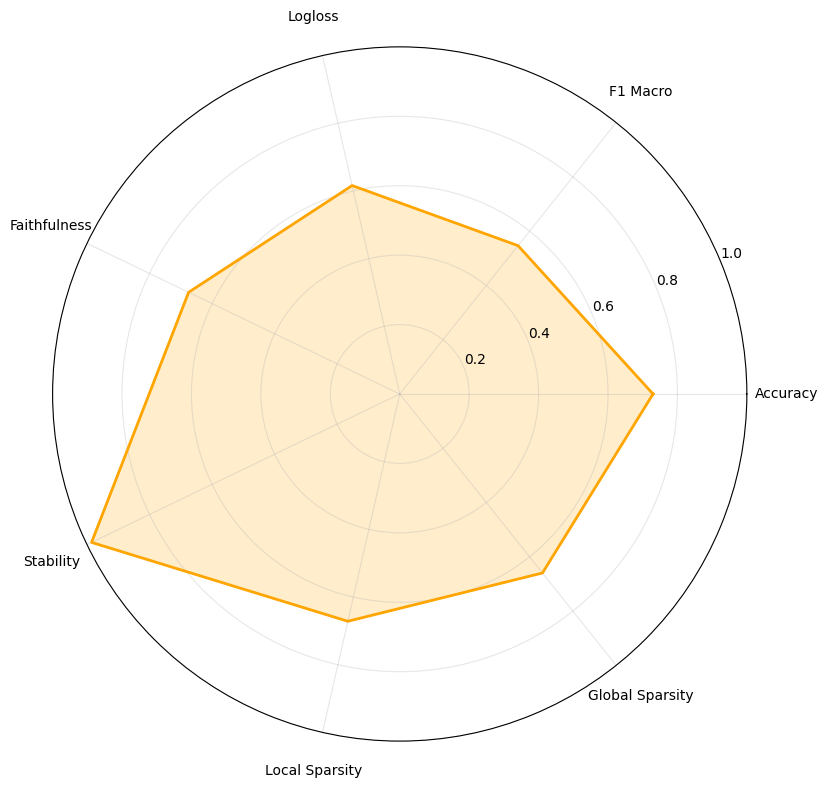

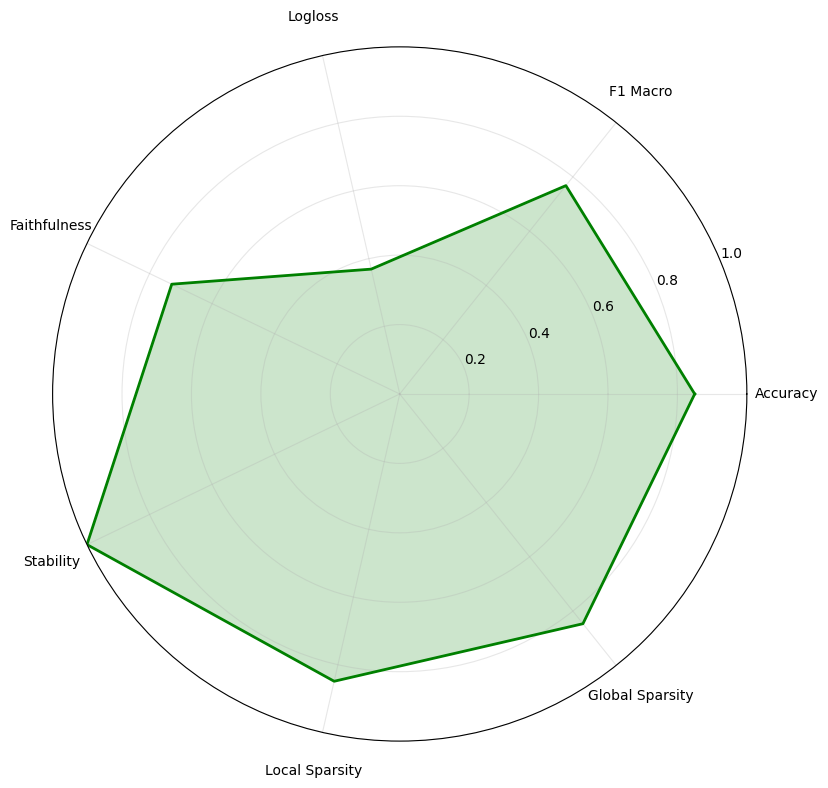

,Model,train_time_mean(s),train_time_std,predict_time_mean(s),predict_time_std,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,logloss_mean,...,faithfulness_mean,faithfulness_std,stability_mean,stability_std,local_sparsity_mean,local_sparsity_std,global_sparsity_mean,global_sparsity_std,transparency_mean,transparency_sd
0,MLP+SHAP,34.497765,0.064681,0.012463,0.001154,0.904158,0.003426,0.862805,0.007016,0.240147,...,0.806155,0.017803,0.850145,0.003184,0.675663,0.004615,0.584010,9.389624e-03,N/A,N/A
1,NAM,21.092202,0.933706,0.028148,0.000552,0.729713,0.000654,0.546565,0.014650,0.615884,...,0.675026,0.014512,0.985345,0.003448,0.671577,0.027346,0.659533,3.443867e-02,N/A,N/A
2,LogReg+MLP,5.155677,0.037879,0.012218,0.000101,0.849723,0.006166,0.767725,0.011974,0.368926,...,0.728932,0.033650,1.000000,0.000000,0.848882,0.000000,0.846479,1.241267e-16,0.070858,0.0


In [37]:
plot_model_scoreboard_radar_separate(
    results_df,
    save_path=path_graph,
    save_title="model_scoreboard_radar"
)

results_df

<hr>
<a class="anchor" id="setup">

# Export

In [ ]:
results_df.to_csv("../Results/Cover_type_Experiment_Results.csv", index=False)